# Prueba Técnica – Científico(a) de AI

## Proyecto Voice of Customer (VoC), NLP, IA Generativa y Analítica Conversacional

### 1. Objetivo

El objetivo de este proyecto es analizar conversaciones de WhatsApp entre clientes y asesores de una operación de cobranza, utilizando técnicas de Procesamiento de Lenguaje Natural (NLP), Inteligencia Artificial Generativa y analítica avanzada.

El análisis busca identificar patrones de comportamiento de los clientes, comprender los principales motivos de no pago y evaluar las estrategias de negociación utilizadas por los asesores.

Adicionalmente, se busca determinar qué ofrecimientos o argumentos presentan mayor efectividad en la generación de acuerdos de pago, analizar la experiencia del cliente y proponer una arquitectura basada en Retrieval-Augmented Generation (RAG) que permita estandarizar y mejorar las respuestas utilizadas en la gestión de cobranza.

### 2. Preguntas de negocio

El análisis busca responder las siguientes preguntas:

1. ¿Cuáles son los principales motivos de no pago?
2. ¿Qué ofertas realizan los asesores para lograr acuerdos de pago?
3. ¿Qué argumentos u ofrecimientos generan una mayor tasa de acuerdos de pago?
4. ¿Qué está ocurriendo en cada conversación?
5. ¿Cuáles son las conversaciones con menor satisfacción y qué factores afectan negativamente la experiencia del cliente?

### 3. Definición de acuerdo de pago

Para este análisis se considera que existe un **acuerdo de pago únicamente cuando el cliente manifiesta explícitamente su compromiso de pago e indica una fecha específica**.

Esta definición se utilizará como criterio de negocio para la generación de la variable `acuerdo_pago`.

### 4. Metodología

El proyecto se desarrolla mediante las siguientes etapas:

1. Carga y comprensión de los datos.
2. Análisis Exploratorio de Datos (EDA).
3. Preparación y reconstrucción de las conversaciones.
4. Procesamiento de Lenguaje Natural.
5. Diseño de variables mediante IA Generativa.
6. Prompt Engineering.
7. Identificación de motivos de no pago.
8. Identificación de ofertas y argumentos utilizados por los asesores.
9. Detección de acuerdos de pago.
10. Evaluación de satisfacción y experiencia del cliente.
11. Resumen automático de conversaciones.
12. Análisis de efectividad de estrategias de negociación.
13. Visualización de resultados.
14. Propuesta de arquitectura RAG.
15. Evaluación de la solución.
16. Generación de insights y recomendaciones de negocio.


## 5. Variables analíticas objetivo

A partir de cada conversación se propone construir un dataset enriquecido mediante técnicas de NLP e IA Generativa.

Las principales variables objetivo serán:

| Variable                    | Descripción |
| --------------------------- | ----------- |
| `uk_id_conversacion`        | Identificador único de la conversación |
| `motivo_no_pago`            | Motivo principal manifestado por el cliente |
| `submotivo_no_pago`         | Clasificación más específica del motivo |
| `oferta_asesor`             | Oferta o alternativa presentada por el asesor |
| `tipo_oferta`               | Categoría de la oferta identificada |
| `argumento_asesor`          | Argumento utilizado durante la negociación |
| `acuerdo_pago`              | Indica si se logró un acuerdo de pago según la regla de negocio |
| `fecha_acuerdo`             | Fecha específica comprometida por el cliente |
| `sentimiento_cliente`       | Sentimiento predominante del cliente |
| `nps_score`                 | Puntaje NPS explícito cuando está disponible (0–10) |
| `satisfaccion_encuesta`     | Puntaje explícito de satisfacción cuando está disponible (1–7) |
| `facilidad_score`           | Puntaje explícito de facilidad o esfuerzo cuando está disponible (1–5) |
| `experiencia_ia_score`      | Indicador inferido por IA sobre la experiencia de la conversación (1–5) |
| `factores_negativos`        | Factores identificados que afectan negativamente la experiencia |
| `resumen_conversacion`      | Resumen automático de los principales hechos de la conversación |
| `recomendacion`             | Recomendación de mejora para la gestión |

Estas variables permiten transformar conversaciones no estructuradas en información estructurada y utilizable para análisis de negocio, diferenciando las métricas explícitas de encuesta de los indicadores inferidos mediante IA.

In [2]:
# ============================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import re
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [3]:
# ============================================
# 2. CARGA DE LA BASE DE DATOS
# ============================================

ruta_archivo = "/content/Copia de Base sintetica conversaciones.xlsx"

df = pd.read_excel(ruta_archivo)

print("Dimensiones de la base:")
print(df.shape)

display(df.head())

Dimensiones de la base:
(42607, 8)


,uk_id_conversacion,total_interacciones,anio,mes,de,uk_id_mensaje,uk_id_conversacion1,mensaje
0,CONV_00000001,37,2010,Julio,USUARIO,MSG_00000001,CONV_00000001,HABLAR CON ASESOR
1,CONV_00000001,37,2010,Julio,BOT,MSG_00000002,CONV_00000001,AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA LEY 1581 DEL FECHA_00000213 DE PROTECCIÓN DE DATOS QUE SE ENCUENTRA EN EL SIGUIENTE ENLACE: URL_ANONIMIZADA
2,CONV_00000001,37,2010,Julio,BOT,MSG_00000003,CONV_00000001,"ESTAMOS VALIDANDO TU INFORMACIÓN. EN UN MOMENTO, UNO DE NUESTROS ASESORES TE AYUDARÁ A ENCONTRAR LA MEJOR ALTERNATIVA PARA QUE ESTÉS AL DÍA CON TUS OBLIGACIONES."
3,CONV_00000001,37,2010,Julio,BOT,MSG_00000004,CONV_00000001,"HOLA, MI NOMBRE ES PERSONA_00000134, SOY ASESOR DEL BANCO_000001. POR FAVOR INDÍCAME LA FECHA DE EXPEDICIÓN DE TÚ DOCUMENTO Y EL CORREO ELECTRÓNICO REGISTRADO."
4,CONV_00000001,37,2010,Julio,USUARIO,MSG_00000005,CONV_00000001,FECHA_ANONIMIZADA


In [4]:
# ============================================
# 3. INFORMACIÓN GENERAL DEL DATASET
# ============================================

print("Número de registros:", len(df))
print("Número de variables:", df.shape[1])

print("\nColumnas disponibles:")
for columna in df.columns:
    print("-", columna)

print("\nTipos de datos:")
display(df.dtypes)

Número de registros: 42607
Número de variables: 8

Columnas disponibles:
- uk_id_conversacion
- total_interacciones
- anio
- mes
- de
- uk_id_mensaje
- uk_id_conversacion1
- mensaje

Tipos de datos:


,0
uk_id_conversacion,object
total_interacciones,int64
anio,int64
mes,object
de,object
uk_id_mensaje,object
uk_id_conversacion1,object
mensaje,object


In [5]:
# ============================================
# 4. REVISIÓN DE VALORES NULOS
# ============================================

nulos = pd.DataFrame({
    "cantidad_nulos": df.isnull().sum(),
    "porcentaje_nulos": (df.isnull().sum() / len(df) * 100).round(2)
})

display(nulos.sort_values("cantidad_nulos", ascending=False))

,cantidad_nulos,porcentaje_nulos
mensaje,1,0.0
uk_id_conversacion,0,0.0
anio,0,0.0
total_interacciones,0,0.0
mes,0,0.0
de,0,0.0
uk_id_mensaje,0,0.0
uk_id_conversacion1,0,0.0


In [6]:
# ============================================
# 5. VALIDACIÓN DE LA ESTRUCTURA
# ============================================

display(df.sample(10, random_state=42))

,uk_id_conversacion,total_interacciones,anio,mes,de,uk_id_mensaje,uk_id_conversacion1,mensaje
30236,CONV_00000848,80,2010,Julio,USUARIO,MSG_00029706,CONV_00000848,NO ESTOY DESEMPLEADA
33015,CONV_00000932,21,2010,Julio,HSM,MSG_00032485,CONV_00000932,BANCO_000001 :BLUE_HEART: ¡HOLA!\N\NHEMOS INTENTADO COMUNICARNOS CONTIGO PARA HABLAR SOBRE EL ESTADO DE TUS PRODUCTOS FINANCIEROS.\NTENEMOS OPCIONES PARA QUE LOGRES NORMALIZAR TUS PAGOS Y RECUPERE...
23571,CONV_00000656,20,2010,Julio,USUARIO,MSG_00023140,CONV_00000656,GTACIAS
33308,CONV_00000940,24,2010,Julio,AGENTE,MSG_00032778,CONV_00000940,PERMITAME UN MOMENTO
22186,CONV_00000615,28,2010,Julio,AGENTE,MSG_00021755,CONV_00000615,"EN EL SISTEMA ME REGISTRA CRÉDITO DE VIVIENDA FINALIZADO 8012 VALOR DE CUOTA PARA HOY MONTO_00000988 CON MORA_BAJA, PARA CUANDO TIENES PROGRAMADO TU PAGO Y POR QUE MEDIO?"
3426,CONV_00000099,64,2010,Julio,BOT,MSG_00003399,CONV_00000099,ENTENDEMOS QUE EN ESTE MOMENTO NO FUE POSIBLE CONTINUAR. LA ATENCIÓN SEGUIRÁ DISPONIBLE PARA QUE UN AGENTE PUEDA ACOMPAÑARTE Y CONTINUAR CUANDO LO DESEES.
36953,CONV_00001038,31,2010,Julio,USUARIO,MSG_00036423,CONV_00001038,IMAGE@_@JPG@_@URL_ANONIMIZADA
10741,CONV_00000297,22,2010,Julio,AGENTE,MSG_00010661,CONV_00000297,¿ALGO MAS EN QUE PUEDA AYUDARLE?
32202,CONV_00000907,21,2010,Julio,BOT,MSG_00031672,CONV_00000907,AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA LEY 1581 DEL FECHA_00000213 DE PROTECCIÓN DE DATOS QUE SE ENCUENTRA EN EL SIGUIENTE ENLACE: URL_ANONIMIZADA
27678,CONV_00000776,24,2010,Julio,BOT,MSG_00027247,CONV_00000776,ENTENDEMOS QUE EN ESTE MOMENTO NO FUE POSIBLE CONTINUAR. LA ATENCIÓN SEGUIRÁ DISPONIBLE PARA QUE UN AGENTE PUEDA ACOMPAÑARTE Y CONTINUAR CUANDO LO DESEES.


## 6. Validación de calidad de los datos

Antes de realizar el análisis conversacional se validan duplicados, consistencia de identificadores, valores nulos y distribución de los actores que participan en las conversaciones.

Estas validaciones permiten identificar posibles problemas de calidad antes de construir las variables mediante NLP e IA Generativa.

In [7]:
# ============================================
# 6. VALIDACIONES DE CALIDAD
# ============================================

print("Mensajes duplicados por ID:")
print(df["uk_id_mensaje"].duplicated().sum())

print("\nConversaciones únicas:")
print(df["uk_id_conversacion"].nunique())

print("\n¿Los dos identificadores de conversación son iguales?")
print((df["uk_id_conversacion"] == df["uk_id_conversacion1"]).all())

print("\nDistribución por tipo de emisor:")
display(
    df["de"]
    .value_counts()
    .rename_axis("emisor")
    .reset_index(name="cantidad")
)

Mensajes duplicados por ID:
602

Conversaciones únicas:
1197

¿Los dos identificadores de conversación son iguales?
True

Distribución por tipo de emisor:


,emisor,cantidad
0,USUARIO,18873
1,AGENTE,13952
2,BOT,8538
3,HSM,1244


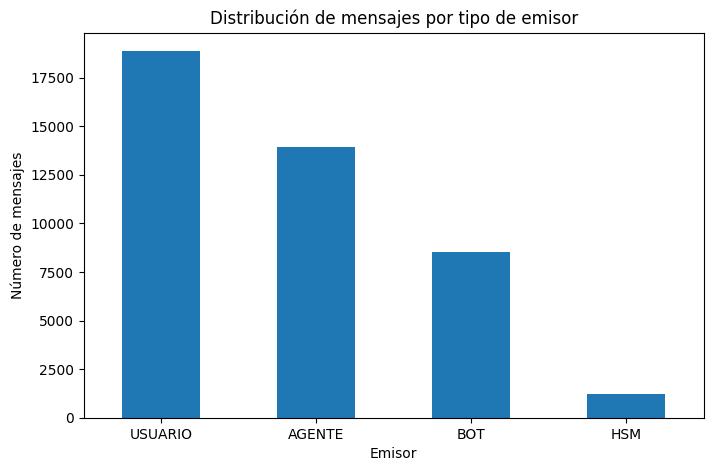

In [8]:
# ============================================
# 7. DISTRIBUCIÓN DE MENSAJES POR EMISOR
# ============================================

distribucion_emisor = df["de"].value_counts()

plt.figure(figsize=(8,5))
distribucion_emisor.plot(kind="bar")

plt.title("Distribución de mensajes por tipo de emisor")
plt.xlabel("Emisor")
plt.ylabel("Número de mensajes")
plt.xticks(rotation=0)

plt.show()

In [9]:
# ============================================
# 8. ESTADÍSTICAS DE LAS CONVERSACIONES
# ============================================

mensajes_por_conversacion = (
    df.groupby("uk_id_conversacion")
      .size()
      .reset_index(name="numero_mensajes")
)

display(mensajes_por_conversacion.describe())

,numero_mensajes
count,1197.000000
mean,35.594820
std,18.674927
min,20.000000
25%,24.000000
50%,29.000000
75%,40.000000
max,228.000000


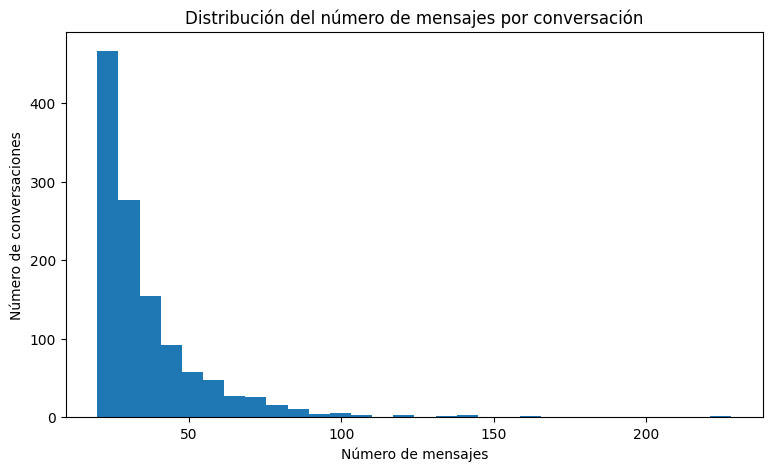

In [10]:
plt.figure(figsize=(9,5))

plt.hist(
    mensajes_por_conversacion["numero_mensajes"],
    bins=30
)

plt.title("Distribución del número de mensajes por conversación")
plt.xlabel("Número de mensajes")
plt.ylabel("Número de conversaciones")

plt.show()

In [11]:
# ============================================
# 9. LONGITUD DE LOS MENSAJES
# ============================================

df["mensaje"] = df["mensaje"].fillna("")

df["longitud_mensaje"] = df["mensaje"].str.len()
df["numero_palabras"] = df["mensaje"].str.split().str.len()

display(
    df[["longitud_mensaje", "numero_palabras"]]
    .describe()
)

,longitud_mensaje,numero_palabras
count,42607.000000,42607.000000
mean,93.338090,15.087403
std,103.065287,16.084282
min,0.000000,0.000000
25%,22.000000,3.000000
50%,59.000000,10.000000
75%,152.000000,24.000000
max,1151.000000,256.000000


In [12]:
# ============================================
# 10. VALIDACIÓN DE TOTAL_INTERACCIONES
# ============================================

validacion_interacciones = (
    df.groupby("uk_id_conversacion")
      .agg(
          mensajes_reales=("uk_id_mensaje", "count"),
          total_interacciones=("total_interacciones", "first")
      )
      .reset_index()
)

validacion_interacciones["coincide"] = (
    validacion_interacciones["mensajes_reales"]
    == validacion_interacciones["total_interacciones"]
)

display(validacion_interacciones.head())

print(
    "Porcentaje de conversaciones donde coincide:",
    round(validacion_interacciones["coincide"].mean() * 100, 2),
    "%"
)

,uk_id_conversacion,mensajes_reales,total_interacciones,coincide
0,CONV_00000001,37,37,True
1,CONV_00000002,38,38,True
2,CONV_00000003,27,27,True
3,CONV_00000004,22,22,True
4,CONV_00000005,92,92,True


Porcentaje de conversaciones donde coincide: 99.16 %


In [13]:
# ============================================
# 11. ORDEN DE LOS MENSAJES
# ============================================

df["orden_mensaje"] = (
    df["uk_id_mensaje"]
      .str.extract(r"(\d+)")
      .astype(int)
)

df = df.sort_values(
    ["uk_id_conversacion", "orden_mensaje"]
).reset_index(drop=True)

display(
    df[
        [
            "uk_id_conversacion",
            "orden_mensaje",
            "de",
            "mensaje"
        ]
    ].head(15)
)

,uk_id_conversacion,orden_mensaje,de,mensaje
0,CONV_00000001,1,USUARIO,HABLAR CON ASESOR
1,CONV_00000001,2,BOT,AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA LEY 1581 DEL FECHA_00000213 DE PROTECCIÓN DE DATOS QUE SE ENCUENTRA EN EL SIGUIENTE ENLACE: URL_ANONIMIZADA
2,CONV_00000001,3,BOT,"ESTAMOS VALIDANDO TU INFORMACIÓN. EN UN MOMENTO, UNO DE NUESTROS ASESORES TE AYUDARÁ A ENCONTRAR LA MEJOR ALTERNATIVA PARA QUE ESTÉS AL DÍA CON TUS OBLIGACIONES."
3,CONV_00000001,4,BOT,"HOLA, MI NOMBRE ES PERSONA_00000134, SOY ASESOR DEL BANCO_000001. POR FAVOR INDÍCAME LA FECHA DE EXPEDICIÓN DE TÚ DOCUMENTO Y EL CORREO ELECTRÓNICO REGISTRADO."
4,CONV_00000001,5,USUARIO,FECHA_ANONIMIZADA
5,CONV_00000001,6,USUARIO,DOCUMENTO_00000001 EMAIL_00000001
6,CONV_00000001,7,AGENTE,¿CUÉNTAME EN QUÉ TE PUEDO AYUDAR?
7,CONV_00000001,8,USUARIO,PODRÍAS ENVIARME EL VALOR A PAGAR DE MI CRÉDITO Y EL SALDO QUE TENGO GRACIAS
8,CONV_00000001,9,USUARIO,DEBÍA HABER PAGADO EL FECHA_ANONIMIZADA
9,CONV_00000001,10,AGENTE,TÚ CRÉDITO DE PRODUCTO_LIBRANZA TERMINADO EN CREDITO_00000001 CON MORA_BAJA POR VALOR DE MONTO_00000001


In [14]:
# ============================================
# 12. RECONSTRUCCIÓN DE LAS CONVERSACIONES
# ============================================

df["intervencion"] = (
    df["de"].astype(str)
    + ": "
    + df["mensaje"].astype(str)
)

In [15]:
conversaciones = (
    df.groupby("uk_id_conversacion")
      .agg(
          anio=("anio", "first"),
          mes=("mes", "first"),
          numero_mensajes=("uk_id_mensaje", "count"),
          conversacion=("intervencion", lambda x: "\n".join(x))
      )
      .reset_index()
)

print("Dimensiones de la nueva base:")
print(conversaciones.shape)

display(conversaciones.head())

Dimensiones de la nueva base:
(1197, 5)


,uk_id_conversacion,anio,mes,numero_mensajes,conversacion
0,CONV_00000001,2010,Julio,37,USUARIO: HABLAR CON ASESOR\nBOT: AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA LEY 1581 DEL FECHA_00000213 DE PROTECCIÓN DE DATOS QUE SE ENCUENTRA EN EL SIGUIENTE ENLACE: ...
1,CONV_00000002,2010,Julio,38,"HSM: BANCO_000001 :BLUE_HEART: ¡HOLA!\NSABEMOS QUE TU HOGAR ES TU MAYOR TRANQUILIDAD.\NPOR ESO, SI TIENES UNA CUOTA PENDIENTE, QUEREMOS OFRECERTE ALTERNATIVAS QUE TE PERMITAN PONERTE AL DÍA SIN CO..."
2,CONV_00000003,2010,Julio,27,"HSM: BANCO_000001 :BLUE_HEART: ¡HOLA!.\NENTENDEMOS QUE A VECES SURGEN IMPREVISTOS.\NPOR ESO, HEMOS CREADO SOLUCIONES PERSONALIZADAS PARA AYUDARTE A PONERTE AL DÍA SIN AFECTAR TU PRESUPUESTO.\NNUES..."
3,CONV_00000004,2010,Julio,22,"HSM: :STAR2: TU CRÉDITO SIEMPRE PROTEGIDO :STAR2:\NQUEREMOS RECORDARTE QUE TU CRÉDITO DE PRODUCTO_LIBRANZA INCLUYE UN SEGURO DE CUOTA PROTEGIDA, DISEÑADO PARA RESPALDARTE EN CASO DE DESEMPLEO.\N\N..."
4,CONV_00000005,2010,Julio,92,HSM: BANCO_000001 ???? ¡HOLA!\nQUEREMOS CONTARTE QUE TIENES UNA EXCELENTE OPORTUNIDAD PARA PONERTE AL DÍA CON TUS PRODUCTOS FINANCIEROS.\nHEMOS DISEÑADO ALTERNATIVAS FLEXIBLES QUE SE AJUSTEN A TU ...


In [16]:
conversaciones.shape

(1197, 5)

In [17]:
print(conversaciones.loc[0, "conversacion"])

USUARIO: HABLAR CON ASESOR
BOT: AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA LEY 1581 DEL FECHA_00000213 DE PROTECCIÓN DE DATOS QUE SE ENCUENTRA EN EL SIGUIENTE ENLACE: URL_ANONIMIZADA
BOT: ESTAMOS VALIDANDO TU INFORMACIÓN. EN UN MOMENTO, UNO DE NUESTROS ASESORES TE AYUDARÁ A ENCONTRAR LA MEJOR ALTERNATIVA PARA QUE ESTÉS AL DÍA CON TUS OBLIGACIONES.
BOT: HOLA, MI NOMBRE ES PERSONA_00000134, SOY ASESOR DEL BANCO_000001. POR FAVOR INDÍCAME LA FECHA DE EXPEDICIÓN DE TÚ DOCUMENTO Y EL CORREO ELECTRÓNICO REGISTRADO.
USUARIO: FECHA_ANONIMIZADA
USUARIO: DOCUMENTO_00000001 EMAIL_00000001
AGENTE: ¿CUÉNTAME EN QUÉ TE PUEDO AYUDAR?
USUARIO: PODRÍAS ENVIARME EL VALOR A PAGAR DE MI CRÉDITO Y EL SALDO QUE TENGO GRACIAS
USUARIO: DEBÍA HABER PAGADO EL FECHA_ANONIMIZADA
AGENTE: TÚ CRÉDITO DE PRODUCTO_LIBRANZA TERMINADO EN CREDITO_00000001 CON MORA_BAJA POR VALOR DE MONTO_00000001
AGENTE: ¿CONTAMOS CON TU PAGO PARA EL DÍA DE HOY?
USUARIO: GRACIAS
USUARIO: SI SEÑORA
USUARIO: POD

## 7. Hallazgos de calidad de datos

Durante la validación inicial se identificaron los siguientes aspectos:

- Se encontraron 1.197 conversaciones únicas.
- La base contiene 42.607 registros de mensajes.
- Los identificadores `uk_id_conversacion` y `uk_id_conversacion1` son equivalentes.
- Se detectaron 602 identificadores de mensaje duplicados.
- Antes de la depuración, la variable `total_interacciones` coincidía con el número real de mensajes en el 99,16% de las conversaciones.
- Se identificaron cuatro tipos de emisor: USUARIO, AGENTE, BOT y HSM.

Estos hallazgos fueron considerados antes de construir el dataset conversacional final.

In [18]:
# ============================================
# 13. REVISIÓN DE IDs DE MENSAJE DUPLICADOS
# ============================================

duplicados_id = df[df["uk_id_mensaje"].duplicated(keep=False)].copy()

print("Filas involucradas en IDs duplicados:")
print(len(duplicados_id))

display(
    duplicados_id[
        [
            "uk_id_mensaje",
            "uk_id_conversacion",
            "de",
            "mensaje"
        ]
    ]
    .sort_values("uk_id_mensaje")
    .head(30)
)

Filas involucradas en IDs duplicados:
955


,uk_id_mensaje,uk_id_conversacion,de,mensaje
946,MSG_00000947,CONV_00000027,HSM,BANCO_000001 :BLUE_HEART: ¡HOLA!\NHEMOS INTENTADO COMUNICARNOS CONTIGO POR DIFERENTES CPERSONA_00000008LES SIN ÉXITO.\NQUEREMOS ESCUCHARTE Y BRINDARTE ASESORÍA PARA QUE TE PERMITA PONERTE AL DÍA C...
947,MSG_00000947,CONV_00000027,HSM,BANCO_000001 :BLUE_HEART: ¡HOLA!\NHEMOS INTENTADO COMUNICARNOS CONTIGO POR DIFERENTES CPERSONA_00000008LES SIN ÉXITO.\NQUEREMOS ESCUCHARTE Y BRINDARTE ASESORÍA PARA QUE TE PERMITA PONERTE AL DÍA C...
948,MSG_00000948,CONV_00000027,USUARIO,ME INTERESA
949,MSG_00000948,CONV_00000027,USUARIO,ME INTERESA
950,MSG_00000949,CONV_00000027,BOT,"HOLA, TE DAMOS LA BIENVENIDA A NUESTRO CPERSONA_00000008L DIGITAL DE NEGOCIACIÓN DE BANCO_000001, DEL LADO DE LOS QUE HACEN. AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA ..."
951,MSG_00000949,CONV_00000027,BOT,"HOLA, TE DAMOS LA BIENVENIDA A NUESTRO CPERSONA_00000008L DIGITAL DE NEGOCIACIÓN DE BANCO_000001, DEL LADO DE LOS QUE HACEN. AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA ..."
952,MSG_00000950,CONV_00000027,BOT,POR FAVOR INGRESA TU NOMBRE.
953,MSG_00000950,CONV_00000027,BOT,POR FAVOR INGRESA TU NOMBRE.
954,MSG_00000951,CONV_00000027,USUARIO,BAUTISTA HOYOS
955,MSG_00000951,CONV_00000027,USUARIO,BAUTISTA HOYOS


In [ ]:
# ¿Existen filas completamente duplicadas?
duplicados_completos = df.duplicated().sum()

print("Filas completamente duplicadas:", duplicados_completos)

Filas completamente duplicadas: 602


In [19]:
# Cantidad de mensajes distintos asociados a un mismo ID
revision_ids = (
    duplicados_id
    .groupby("uk_id_mensaje")
    .agg(
        conversaciones=("uk_id_conversacion", "nunique"),
        mensajes_distintos=("mensaje", "nunique"),
        emisores=("de", "nunique"),
        registros=("uk_id_mensaje", "size")
    )
    .reset_index()
)

display(revision_ids.head(20))

,uk_id_mensaje,conversaciones,mensajes_distintos,emisores,registros
0,MSG_00000947,1,1,1,2
1,MSG_00000948,1,1,1,2
2,MSG_00000949,1,1,1,2
3,MSG_00000950,1,1,1,2
4,MSG_00000951,1,1,1,2
5,MSG_00000952,1,1,1,2
6,MSG_00000953,1,1,1,2
7,MSG_00000954,1,1,1,2
8,MSG_00000955,1,1,1,2
9,MSG_00000956,1,1,1,2


In [20]:
# ============================================
# 14. VARIABLES BÁSICAS POR CONVERSACIÓN
# ============================================

metricas_conversacion = (
    df.groupby("uk_id_conversacion")
      .agg(
          total_mensajes=("uk_id_mensaje", "size"),
          mensajes_usuario=("de", lambda x: (x == "USUARIO").sum()),
          mensajes_agente=("de", lambda x: (x == "AGENTE").sum()),
          mensajes_bot=("de", lambda x: (x == "BOT").sum()),
          mensajes_hsm=("de", lambda x: (x == "HSM").sum()),
          total_palabras=("numero_palabras", "sum")
      )
      .reset_index()
)

conversaciones = conversaciones.merge(
    metricas_conversacion,
    on="uk_id_conversacion",
    how="left"
)

display(conversaciones.head())

,uk_id_conversacion,anio,mes,numero_mensajes,conversacion,total_mensajes,mensajes_usuario,mensajes_agente,mensajes_bot,mensajes_hsm,total_palabras
0,CONV_00000001,2010,Julio,37,USUARIO: HABLAR CON ASESOR\nBOT: AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA LEY 1581 DEL FECHA_00000213 DE PROTECCIÓN DE DATOS QUE SE ENCUENTRA EN EL SIGUIENTE ENLACE: ...,37,15,9,12,1,515
1,CONV_00000002,2010,Julio,38,"HSM: BANCO_000001 :BLUE_HEART: ¡HOLA!\NSABEMOS QUE TU HOGAR ES TU MAYOR TRANQUILIDAD.\NPOR ESO, SI TIENES UNA CUOTA PENDIENTE, QUEREMOS OFRECERTE ALTERNATIVAS QUE TE PERMITAN PONERTE AL DÍA SIN CO...",38,19,9,9,1,462
2,CONV_00000003,2010,Julio,27,"HSM: BANCO_000001 :BLUE_HEART: ¡HOLA!.\NENTENDEMOS QUE A VECES SURGEN IMPREVISTOS.\NPOR ESO, HEMOS CREADO SOLUCIONES PERSONALIZADAS PARA AYUDARTE A PONERTE AL DÍA SIN AFECTAR TU PRESUPUESTO.\NNUES...",27,10,10,6,1,375
3,CONV_00000004,2010,Julio,22,"HSM: :STAR2: TU CRÉDITO SIEMPRE PROTEGIDO :STAR2:\NQUEREMOS RECORDARTE QUE TU CRÉDITO DE PRODUCTO_LIBRANZA INCLUYE UN SEGURO DE CUOTA PROTEGIDA, DISEÑADO PARA RESPALDARTE EN CASO DE DESEMPLEO.\N\N...",22,8,7,6,1,420
4,CONV_00000005,2010,Julio,92,HSM: BANCO_000001 ???? ¡HOLA!\nQUEREMOS CONTARTE QUE TIENES UNA EXCELENTE OPORTUNIDAD PARA PONERTE AL DÍA CON TUS PRODUCTOS FINANCIEROS.\nHEMOS DISEÑADO ALTERNATIVAS FLEXIBLES QUE SE AJUSTEN A TU ...,92,48,36,7,1,885


In [21]:
# Participación del cliente dentro de la conversación
conversaciones["participacion_usuario"] = (
    conversaciones["mensajes_usuario"]
    / conversaciones["total_mensajes"]
)

conversaciones["participacion_agente"] = (
    conversaciones["mensajes_agente"]
    / conversaciones["total_mensajes"]
)

display(
    conversaciones[
        [
            "uk_id_conversacion",
            "total_mensajes",
            "mensajes_usuario",
            "mensajes_agente",
            "participacion_usuario",
            "participacion_agente"
        ]
    ].head()
)

,uk_id_conversacion,total_mensajes,mensajes_usuario,mensajes_agente,participacion_usuario,participacion_agente
0,CONV_00000001,37,15,9,0.405405,0.243243
1,CONV_00000002,38,19,9,0.500000,0.236842
2,CONV_00000003,27,10,10,0.370370,0.370370
3,CONV_00000004,22,8,7,0.363636,0.318182
4,CONV_00000005,92,48,36,0.521739,0.391304


In [22]:
# ============================================
# 15. ELIMINACIÓN DE DUPLICADOS EXACTOS
# ============================================

df_clean = df.drop_duplicates().copy()

print("Registros originales:", len(df))
print("Registros después de eliminar duplicados:", len(df_clean))
print("Registros eliminados:", len(df) - len(df_clean))

print("\nConversaciones antes:", df["uk_id_conversacion"].nunique())
print("Conversaciones después:", df_clean["uk_id_conversacion"].nunique())

Registros originales: 42607
Registros después de eliminar duplicados: 42005
Registros eliminados: 602

Conversaciones antes: 1197
Conversaciones después: 1197


### Tratamiento de duplicados

Durante la validación se identificaron 602 filas completamente duplicadas.

La inspección mostró que los registros duplicados contenían el mismo identificador
de mensaje, identificador de conversación, emisor y contenido textual.

Por esta razón, se eliminaron únicamente los duplicados exactos, conservando intactos
los mensajes legítimos que pudieran contener textos iguales dentro o entre conversaciones.

Se mantuvo una copia de la base original con el fin de conservar la trazabilidad
del proceso de preparación de datos.

In [23]:
# ============================================
# 16. ORDENAMIENTO DE LA BASE LIMPIA
# ============================================

df_clean["orden_mensaje"] = (
    df_clean["uk_id_mensaje"]
    .str.extract(r"(\d+)")
    .astype(int)
)

df_clean = (
    df_clean
    .sort_values(["uk_id_conversacion", "orden_mensaje"])
    .reset_index(drop=True)
)

print("Base limpia y ordenada correctamente.")

Base limpia y ordenada correctamente.


In [24]:
df_clean["mensaje"] = df_clean["mensaje"].fillna("")

df_clean["longitud_mensaje"] = df_clean["mensaje"].str.len()

df_clean["numero_palabras"] = (
    df_clean["mensaje"]
    .str.split()
    .str.len()
)

In [25]:
df_clean["intervencion"] = (
    df_clean["de"].astype(str)
    + ": "
    + df_clean["mensaje"].astype(str)
)

In [26]:
# ============================================
# 17. RECONSTRUCCIÓN DE CONVERSACIONES LIMPIAS
# ============================================

conversaciones = (
    df_clean.groupby("uk_id_conversacion")
    .agg(
        anio=("anio", "first"),
        mes=("mes", "first"),
        numero_mensajes=("uk_id_mensaje", "count"),
        conversacion=("intervencion", lambda x: "\n".join(x))
    )
    .reset_index()
)

print("Dimensiones:")
print(conversaciones.shape)

display(conversaciones.head())

Dimensiones:
(1197, 5)


,uk_id_conversacion,anio,mes,numero_mensajes,conversacion
0,CONV_00000001,2010,Julio,37,USUARIO: HABLAR CON ASESOR\nBOT: AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA LEY 1581 DEL FECHA_00000213 DE PROTECCIÓN DE DATOS QUE SE ENCUENTRA EN EL SIGUIENTE ENLACE: ...
1,CONV_00000002,2010,Julio,38,"HSM: BANCO_000001 :BLUE_HEART: ¡HOLA!\NSABEMOS QUE TU HOGAR ES TU MAYOR TRANQUILIDAD.\NPOR ESO, SI TIENES UNA CUOTA PENDIENTE, QUEREMOS OFRECERTE ALTERNATIVAS QUE TE PERMITAN PONERTE AL DÍA SIN CO..."
2,CONV_00000003,2010,Julio,27,"HSM: BANCO_000001 :BLUE_HEART: ¡HOLA!.\NENTENDEMOS QUE A VECES SURGEN IMPREVISTOS.\NPOR ESO, HEMOS CREADO SOLUCIONES PERSONALIZADAS PARA AYUDARTE A PONERTE AL DÍA SIN AFECTAR TU PRESUPUESTO.\NNUES..."
3,CONV_00000004,2010,Julio,22,"HSM: :STAR2: TU CRÉDITO SIEMPRE PROTEGIDO :STAR2:\NQUEREMOS RECORDARTE QUE TU CRÉDITO DE PRODUCTO_LIBRANZA INCLUYE UN SEGURO DE CUOTA PROTEGIDA, DISEÑADO PARA RESPALDARTE EN CASO DE DESEMPLEO.\N\N..."
4,CONV_00000005,2010,Julio,92,HSM: BANCO_000001 ???? ¡HOLA!\nQUEREMOS CONTARTE QUE TIENES UNA EXCELENTE OPORTUNIDAD PARA PONERTE AL DÍA CON TUS PRODUCTOS FINANCIEROS.\nHEMOS DISEÑADO ALTERNATIVAS FLEXIBLES QUE SE AJUSTEN A TU ...


In [27]:
# ============================================
# 18. MÉTRICAS CONVERSACIONALES
# ============================================

metricas_conversacion = (
    df_clean.groupby("uk_id_conversacion")
    .agg(
        total_mensajes=("uk_id_mensaje", "size"),

        mensajes_usuario=(
            "de",
            lambda x: (x == "USUARIO").sum()
        ),

        mensajes_agente=(
            "de",
            lambda x: (x == "AGENTE").sum()
        ),

        mensajes_bot=(
            "de",
            lambda x: (x == "BOT").sum()
        ),

        mensajes_hsm=(
            "de",
            lambda x: (x == "HSM").sum()
        ),

        total_palabras=("numero_palabras", "sum")
    )
    .reset_index()
)

conversaciones = conversaciones.merge(
    metricas_conversacion,
    on="uk_id_conversacion",
    how="left"
)

In [28]:
conversaciones["participacion_usuario"] = (
    conversaciones["mensajes_usuario"]
    / conversaciones["total_mensajes"]
)

conversaciones["participacion_agente"] = (
    conversaciones["mensajes_agente"]
    / conversaciones["total_mensajes"]
)

In [29]:
display(
    conversaciones[
        [
            "uk_id_conversacion",
            "total_mensajes",
            "mensajes_usuario",
            "mensajes_agente",
            "mensajes_bot",
            "mensajes_hsm",
            "participacion_usuario",
            "participacion_agente"
        ]
    ].head()
)

,uk_id_conversacion,total_mensajes,mensajes_usuario,mensajes_agente,mensajes_bot,mensajes_hsm,participacion_usuario,participacion_agente
0,CONV_00000001,37,15,9,12,1,0.405405,0.243243
1,CONV_00000002,38,19,9,9,1,0.500000,0.236842
2,CONV_00000003,27,10,10,6,1,0.370370,0.370370
3,CONV_00000004,22,8,7,6,1,0.363636,0.318182
4,CONV_00000005,92,48,36,7,1,0.521739,0.391304


In [30]:
# Conversaciones que contenían duplicados exactos

filas_duplicadas = df[df.duplicated(keep=False)]

conversaciones_con_duplicados = (
    filas_duplicadas["uk_id_conversacion"].nunique()
)

print(
    "Conversaciones afectadas por duplicados:",
    conversaciones_con_duplicados
)

print(
    "Porcentaje de conversaciones afectadas:",
    round(
        conversaciones_con_duplicados
        / df["uk_id_conversacion"].nunique()
        * 100,
        2
    ),
    "%"
)

Conversaciones afectadas por duplicados: 10
Porcentaje de conversaciones afectadas: 0.84 %


In [31]:
validacion_interacciones_clean = (
    df_clean.groupby("uk_id_conversacion")
    .agg(
        mensajes_limpios=("uk_id_mensaje", "count"),
        total_interacciones_origen=("total_interacciones", "first")
    )
    .reset_index()
)

validacion_interacciones_clean["coincide"] = (
    validacion_interacciones_clean["mensajes_limpios"]
    ==
    validacion_interacciones_clean["total_interacciones_origen"]
)

print(
    "Coincidencia después de depuración:",
    round(
        validacion_interacciones_clean["coincide"].mean() * 100,
        2
    ),
    "%"
)

Coincidencia después de depuración: 100.0 %


### Resultado de la depuración

Se identificaron 602 registros completamente duplicados, concentrados en 10 conversaciones, equivalentes al 0,84% del total.

Después de eliminar únicamente los duplicados exactos:

- Se conservaron las 1.197 conversaciones.
- La variable `total_interacciones` presentó una coincidencia del 100% con el número real de mensajes.
- La base resultante se considera consistente para continuar con el análisis conversacional.

Esta validación permitió garantizar que las métricas posteriores no estuvieran sesgadas por registros duplicados.

## 8. Diseño de variables mediante IA Generativa

A partir de las conversaciones depuradas se construyen variables estructuradas utilizando IA Generativa.

El objetivo es transformar el contenido no estructurado de cada conversación en información analítica que permita responder las preguntas de negocio relacionadas con:

- Motivos de no pago.
- Ofertas realizadas por los asesores.
- Argumentos utilizados durante la negociación.
- Identificación de acuerdos de pago.
- Fecha del compromiso.
- Sentimiento del cliente.
- Nivel de satisfacción.
- Factores que afectan negativamente la experiencia.
- Resumen de la conversación.
- Recomendaciones de mejora.

Para reducir la variabilidad en las respuestas del modelo y facilitar el análisis posterior, se utilizan categorías controladas y reglas explícitas de clasificación.

### 8.1 Definición de categorías de análisis

In [32]:
# ============================================
# 19. CATEGORÍAS DE ANÁLISIS
# ============================================

categorias_motivo = [
    "Falta de liquidez",
    "Desempleo o pérdida de ingresos",
    "Problemas de salud",
    "Gastos imprevistos",
    "Inconformidad con la deuda",
    "Desconocimiento o falta de información",
    "Olvido o descuido",
    "Fecha de pago aún no llegada",
    "Problemas con medios de pago",
    "Prioridad de otros gastos",
    "No manifiesta motivo",
    "Otro"
]

categorias_oferta = [
    "Pago total",
    "Pago parcial",
    "Extensión o nueva fecha de pago",
    "Acuerdo de pago",
    "Descuento o beneficio",
    "Refinanciación o reestructuración",
    "Alternativa de canal de pago",
    "Información de saldo",
    "No realiza oferta",
    "Otro"
]

categorias_sentimiento = [
    "Muy negativo",
    "Negativo",
    "Neutral",
    "Positivo",
    "Muy positivo"
]

print("Categorías definidas correctamente.")

Categorías definidas correctamente.


### 8.2 Regla de negocio para identificar acuerdos de pago

Para este análisis se considera que existe un acuerdo de pago únicamente cuando el cliente manifiesta explícitamente su compromiso de pago y se identifica una fecha específica.

No se consideran acuerdos de pago:

- Intenciones vagas como "voy a pagar".
- Expresiones como "más adelante".
- Frases como "cuando tenga dinero".
- Propuestas realizadas por el asesor que no son aceptadas por el cliente.
- Preguntas del asesor sobre posibles fechas de pago.
- Conversaciones donde no exista una fecha específica asociada al compromiso.

### 8.3 Diseño del prompt de sistema

In [33]:
# ============================================
# 20. PROMPT DE SISTEMA
# ============================================

PROMPT_SISTEMA = """
Eres un especialista en Voice of Customer, analítica conversacional,
Procesamiento de Lenguaje Natural y operaciones de cobranza.

Tu tarea es analizar conversaciones de WhatsApp entre clientes,
asesores, bots y mensajes automatizados.

Debes extraer variables estructuradas de negocio.

REGLA CRÍTICA DE ACUERDO DE PAGO:

Solo existe acuerdo de pago cuando el cliente manifiesta explícitamente
su compromiso de pagar y existe una fecha específica de pago.

No consideres como acuerdo:

- Intención vaga de pagar.
- Frases como "voy a pagar".
- "Más adelante".
- "Cuando tenga dinero".
- Preguntas realizadas por el asesor.
- Propuestas que no hayan sido aceptadas por el cliente.

Si no existe información suficiente, utiliza "No identificado".

No inventes información que no esté presente en la conversación.
"""

print("Prompt de sistema definido.")

Prompt de sistema definido.


### 8.4 Diseño del prompt de extracción de variables

In [34]:
# ============================================
# 21. FUNCIÓN PARA CONSTRUIR EL PROMPT
# ============================================

def construir_prompt(conversacion):

    prompt = f"""
Analiza la siguiente conversación:

---------------- CONVERSACIÓN ----------------
{conversacion}
----------------------------------------------

Clasifica el motivo principal de no pago utilizando únicamente una
de estas categorías:

- Falta de liquidez
- Desempleo o pérdida de ingresos
- Problemas de salud
- Gastos imprevistos
- Inconformidad con la deuda
- Desconocimiento o falta de información
- Olvido o descuido
- Fecha de pago aún no llegada
- Problemas con medios de pago
- Prioridad de otros gastos
- No manifiesta motivo
- Otro

Clasifica la oferta principal realizada por el asesor utilizando:

- Pago total
- Pago parcial
- Extensión o nueva fecha de pago
- Acuerdo de pago
- Descuento o beneficio
- Refinanciación o reestructuración
- Alternativa de canal de pago
- Información de saldo
- No realiza oferta
- Otro

Evalúa también la experiencia del cliente.

Devuelve EXCLUSIVAMENTE un JSON válido con esta estructura:

{{
    "motivo_no_pago": "",
    "submotivo_no_pago": "",
    "oferta_asesor": "",
    "tipo_oferta": "",
    "argumento_asesor": "",
    "acuerdo_pago": false,
    "fecha_acuerdo": null,
    "sentimiento_cliente": "",
    "satisfaccion_score": 0,
    "factores_negativos": [],
    "resumen_conversacion": "",
    "recomendacion": ""
}}

Para satisfaccion_score utiliza una escala de 1 a 5:

1 = experiencia muy negativa
2 = experiencia negativa
3 = experiencia neutral o aceptable
4 = experiencia positiva
5 = experiencia excelente

Considera especialmente:

- Respeto.
- Claridad.
- Empatía.
- Capacidad de resolución.
- Facilidad de la interacción.
- Nivel de fricción.

El resumen debe tener máximo 3 oraciones.

No inventes información.
"""

    return prompt

### 8.5 Validación inicial del prompt

In [35]:
# ============================================
# 22. PRUEBA DE CONSTRUCCIÓN DEL PROMPT
# ============================================

prompt_prueba = construir_prompt(
    conversaciones.loc[0, "conversacion"]
)

print(prompt_prueba[:5000])


Analiza la siguiente conversación:

---------------- CONVERSACIÓN ----------------
USUARIO: HABLAR CON ASESOR
BOT: AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA LEY 1581 DEL FECHA_00000213 DE PROTECCIÓN DE DATOS QUE SE ENCUENTRA EN EL SIGUIENTE ENLACE: URL_ANONIMIZADA
BOT: ESTAMOS VALIDANDO TU INFORMACIÓN. EN UN MOMENTO, UNO DE NUESTROS ASESORES TE AYUDARÁ A ENCONTRAR LA MEJOR ALTERNATIVA PARA QUE ESTÉS AL DÍA CON TUS OBLIGACIONES.
BOT: HOLA, MI NOMBRE ES PERSONA_00000134, SOY ASESOR DEL BANCO_000001. POR FAVOR INDÍCAME LA FECHA DE EXPEDICIÓN DE TÚ DOCUMENTO Y EL CORREO ELECTRÓNICO REGISTRADO.
USUARIO: FECHA_ANONIMIZADA
USUARIO: DOCUMENTO_00000001 EMAIL_00000001
AGENTE: ¿CUÉNTAME EN QUÉ TE PUEDO AYUDAR?
USUARIO: PODRÍAS ENVIARME EL VALOR A PAGAR DE MI CRÉDITO Y EL SALDO QUE TENGO GRACIAS
USUARIO: DEBÍA HABER PAGADO EL FECHA_ANONIMIZADA
AGENTE: TÚ CRÉDITO DE PRODUCTO_LIBRANZA TERMINADO EN CREDITO_00000001 CON MORA_BAJA POR VALOR DE MONTO_00000001
AGENTE: ¿CONTA

### 8.6 Selección de conversaciones para validación manual

In [36]:
# ============================================
# 23. MUESTRA DE CONVERSACIONES
# ============================================

for i in range(5):

    print("=" * 100)
    print("CONVERSACIÓN:", conversaciones.loc[i, "uk_id_conversacion"])
    print("=" * 100)

    print(conversaciones.loc[i, "conversacion"])

    print("\n")

CONVERSACIÓN: CONV_00000001
USUARIO: HABLAR CON ASESOR
BOT: AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA LEY 1581 DEL FECHA_00000213 DE PROTECCIÓN DE DATOS QUE SE ENCUENTRA EN EL SIGUIENTE ENLACE: URL_ANONIMIZADA
BOT: ESTAMOS VALIDANDO TU INFORMACIÓN. EN UN MOMENTO, UNO DE NUESTROS ASESORES TE AYUDARÁ A ENCONTRAR LA MEJOR ALTERNATIVA PARA QUE ESTÉS AL DÍA CON TUS OBLIGACIONES.
BOT: HOLA, MI NOMBRE ES PERSONA_00000134, SOY ASESOR DEL BANCO_000001. POR FAVOR INDÍCAME LA FECHA DE EXPEDICIÓN DE TÚ DOCUMENTO Y EL CORREO ELECTRÓNICO REGISTRADO.
USUARIO: FECHA_ANONIMIZADA
USUARIO: DOCUMENTO_00000001 EMAIL_00000001
AGENTE: ¿CUÉNTAME EN QUÉ TE PUEDO AYUDAR?
USUARIO: PODRÍAS ENVIARME EL VALOR A PAGAR DE MI CRÉDITO Y EL SALDO QUE TENGO GRACIAS
USUARIO: DEBÍA HABER PAGADO EL FECHA_ANONIMIZADA
AGENTE: TÚ CRÉDITO DE PRODUCTO_LIBRANZA TERMINADO EN CREDITO_00000001 CON MORA_BAJA POR VALOR DE MONTO_00000001
AGENTE: ¿CONTAMOS CON TU PAGO PARA EL DÍA DE HOY?
USUARIO: GRACIAS
USU

### 8.7 Validación manual y construcción del Gold Set

Antes de ejecutar el modelo de IA Generativa sobre la totalidad de las conversaciones,
se realizó una revisión manual de una muestra inicial.

El objetivo de esta etapa es:

- Validar que las categorías propuestas representen adecuadamente los casos reales.
- Identificar situaciones no contempladas inicialmente.
- Refinar las reglas utilizadas para detectar acuerdos de pago.
- Establecer ejemplos de referencia para evaluar posteriormente las respuestas del modelo.
- Reducir errores de clasificación y posibles alucinaciones del LLM.

Esta muestra manual constituye un conjunto de referencia o *Gold Set* inicial,
contra el cual se podrá comparar posteriormente la extracción realizada mediante IA.

#### 8.7.1 Hallazgos de la revisión manual

La inspección inicial permitió identificar varios escenarios relevantes:

1. Existen conversaciones en las que el cliente acepta una fecha propuesta por el asesor
mediante respuestas afirmativas como "sí". Estas respuestas deben considerarse como
aceptación explícita cuando la pregunta inmediatamente anterior contiene una fecha concreta.

2. Existen clientes que ya realizaron el pago, por lo que una nueva gestión de cobranza
no debe clasificarse como un motivo tradicional de no pago.

3. Algunas conversaciones no corresponden realmente a una negociación de cartera,
sino a solicitudes administrativas o de información.

4. El desempleo aparece como motivo explícito de imposibilidad de pago y puede activar
alternativas específicas como seguros de desempleo.

5. Una oferta propuesta por el asesor no implica necesariamente un acuerdo de pago.
Debe existir aceptación explícita del cliente.

6. Los mensajes BOT y HSM deben diferenciarse de los argumentos realizados directamente
por un AGENTE, dado que las preguntas de negocio buscan evaluar particularmente
las estrategias utilizadas por los asesores.

### 8.8 Refinamiento de las categorías a partir de la validación manual

In [37]:
# ============================================
# 24. TAXONOMÍA REFINADA
# ============================================

categorias_motivo = [
    "Falta de liquidez",
    "Desempleo o pérdida de ingresos",
    "Problemas de salud",
    "Gastos imprevistos",
    "Inconformidad con la deuda o valor cobrado",
    "Falta de información o extracto",
    "Olvido o descuido",
    "Fecha de pago aún no llegada",
    "Problemas con medios de pago",
    "Prioridad de otros gastos",
    "Pago ya realizado / cliente al día",
    "No manifiesta motivo",
    "No aplica - conversación no relacionada con mora",
    "Otro"
]

categorias_oferta = [
    "Pago total",
    "Pago parcial",
    "Nueva fecha de pago",
    "Acuerdo o compromiso de pago",
    "Descuento o beneficio",
    "Refinanciación o reestructuración",
    "Alternativa de canal de pago",
    "Información de saldo",
    "Seguro o beneficio asociado",
    "Orientación a otro canal o área",
    "No realiza oferta",
    "Otro"
]

categorias_sentimiento = [
    "Muy negativo",
    "Negativo",
    "Neutral",
    "Positivo",
    "Muy positivo"
]

print("Taxonomías refinadas correctamente.")

Taxonomías refinadas correctamente.


### 8.9 Refinamiento de la regla de acuerdo de pago

A partir de la revisión manual se refinó la definición de acuerdo de pago.

Se considera que existe un acuerdo cuando:

1. El cliente manifiesta directamente que realizará un pago e indica una fecha específica; o

2. El asesor propone explícitamente una fecha específica y el cliente manifiesta inmediatamente
su aceptación mediante expresiones inequívocas como "sí", "de acuerdo", "acepto" o equivalentes.

No se considera acuerdo cuando:

- El asesor propone una fecha pero el cliente no responde.
- El cliente rechaza o condiciona la propuesta.
- El cliente manifiesta únicamente intención futura sin fecha.
- El asesor registra unilateralmente un compromiso sin evidencia de aceptación del cliente.
- El cliente manifiesta expresiones como "cuando tenga dinero" o "más adelante".

### 8.10 Estrategia para el cálculo de satisfacción

La satisfacción no será determinada exclusivamente mediante análisis de sentimiento.

Se propone utilizar una estrategia híbrida:

**Prioridad 1 — Voz explícita del cliente**

Cuando existan respuestas a encuestas dentro de la conversación, se utilizarán como
evidencia directa de satisfacción.

Se identificaron principalmente:

- NPS: escala de 0 a 10.
- Satisfacción con alternativas de pago: escala de 1 a 7.
- Facilidad o esfuerzo del cliente: escala de 1 a 5.

**Prioridad 2 — Inferencia mediante IA**

Cuando la conversación no incluya respuestas a encuestas, se utilizará IA Generativa
para estimar la experiencia considerando:

- Sentimiento.
- Respeto.
- Empatía.
- Claridad.
- Resolución.
- Fricción.
- Esfuerzo requerido por el cliente.

De esta manera se evita sustituir información explícita del cliente por una inferencia
del modelo.

###8.11 Gold Set inicial

In [38]:
# ============================================
# 25. GOLD SET INICIAL
# ============================================

gold_set = pd.DataFrame([
    {
        "uk_id_conversacion": "CONV_00000001",
        "motivo_no_pago": "No manifiesta motivo",
        "oferta_asesor": "Acuerdo o compromiso de pago",
        "acuerdo_pago": True,
        "fecha_acuerdo": "02/07",
        "sentimiento_cliente": "Positivo",
        "observacion": "Cliente acepta realizar el pago y se confirma una fecha."
    },

    {
        "uk_id_conversacion": "CONV_00000002",
        "motivo_no_pago": "No aplica - conversación no relacionada con mora",
        "oferta_asesor": "Orientación a otro canal o área",
        "acuerdo_pago": False,
        "fecha_acuerdo": None,
        "sentimiento_cliente": "Neutral",
        "observacion": "Solicitud relacionada con información de un tercero; no existe negociación de pago."
    },

    {
        "uk_id_conversacion": "CONV_00000003",
        "motivo_no_pago": "Pago ya realizado / cliente al día",
        "oferta_asesor": "Información de saldo",
        "acuerdo_pago": False,
        "fecha_acuerdo": None,
        "sentimiento_cliente": "Positivo",
        "observacion": "Cliente informa que ya realizó el pago y el asesor confirma que está al día."
    },

    {
        "uk_id_conversacion": "CONV_00000004",
        "motivo_no_pago": "Desempleo o pérdida de ingresos",
        "oferta_asesor": "Seguro o beneficio asociado",
        "acuerdo_pago": False,
        "fecha_acuerdo": None,
        "sentimiento_cliente": "Neutral",
        "observacion": "Cliente manifiesta desempleo y falta de capacidad de pago; se orienta sobre seguro."
    },

    {
        "uk_id_conversacion": "CONV_00000005",
        "motivo_no_pago": "Falta de información o extracto",
        "oferta_asesor": "Acuerdo o compromiso de pago",
        "acuerdo_pago": False,
        "fecha_acuerdo": None,
        "sentimiento_cliente": "Negativo",
        "observacion": "El asesor propone fecha de pago, pero el cliente no acepta y condiciona el pago a recibir el extracto."
    }
])

display(gold_set)

,uk_id_conversacion,motivo_no_pago,oferta_asesor,acuerdo_pago,fecha_acuerdo,sentimiento_cliente,observacion
0,CONV_00000001,No manifiesta motivo,Acuerdo o compromiso de pago,True,02/07,Positivo,Cliente acepta realizar el pago y se confirma una fecha.
1,CONV_00000002,No aplica - conversación no relacionada con mora,Orientación a otro canal o área,False,None,Neutral,Solicitud relacionada con información de un tercero; no existe negociación de pago.
2,CONV_00000003,Pago ya realizado / cliente al día,Información de saldo,False,None,Positivo,Cliente informa que ya realizó el pago y el asesor confirma que está al día.
3,CONV_00000004,Desempleo o pérdida de ingresos,Seguro o beneficio asociado,False,None,Neutral,Cliente manifiesta desempleo y falta de capacidad de pago; se orienta sobre seguro.
4,CONV_00000005,Falta de información o extracto,Acuerdo o compromiso de pago,False,None,Negativo,"El asesor propone fecha de pago, pero el cliente no acepta y condiciona el pago a recibir el extracto."


## 9. Implementación de IA Generativa

En esta etapa se implementa un modelo de lenguaje para analizar cada conversación
y transformar el texto no estructurado en variables analíticas.

La implementación se realizará inicialmente sobre el Gold Set construido manualmente.
Los resultados del modelo serán comparados contra esta referencia antes de escalar
el procesamiento a la totalidad de las 1.197 conversaciones.

Este enfoque permite:

- Validar la calidad de las variables generadas por IA.
- Identificar errores de clasificación.
- Ajustar el prompt antes de realizar el procesamiento masivo.
- Reducir el riesgo de alucinaciones.
- Evaluar la consistencia de la extracción.

### 9.1 Configuración del modelo

In [39]:
# ============================================
# 26. INSTALACIÓN DEL SDK DE GEMINI
# ============================================

!pip install -q google-genai pydantic

In [40]:
from google.colab import userdata
from google import genai

api_key = userdata.get("GEMINI_API_KEY")

client = genai.Client(api_key=api_key)

print("Cliente de Gemini configurado correctamente.")

Cliente de Gemini configurado correctamente.


### 9.2 Esquema estructurado de las variables generadas por IA

Para garantizar consistencia en las respuestas del modelo y facilitar su integración con Python, se define una estructura de salida obligatoria.

Esta estructura permitirá que cada conversación sea transformada en un conjunto estandarizado de variables analíticas, evitando respuestas abiertas difíciles de procesar.

In [41]:
# ============================================
# 28. ESQUEMA DE SALIDA ESTRUCTURADA
# ============================================

from pydantic import BaseModel, Field
from typing import List, Optional


class AnalisisConversacion(BaseModel):

    motivo_no_pago: str = Field(
        description="Motivo principal de no pago según la taxonomía definida."
    )

    submotivo_no_pago: str = Field(
        description="Descripción específica del motivo identificado."
    )

    oferta_asesor: str = Field(
        description="Oferta principal realizada directamente por el asesor."
    )

    tipo_oferta: str = Field(
        description="Categoría general de la oferta."
    )

    argumento_asesor: str = Field(
        description="Principal argumento utilizado por el asesor para incentivar el pago."
    )

    acuerdo_pago: bool = Field(
        description="True únicamente cuando existe aceptación explícita y una fecha específica."
    )

    fecha_acuerdo: Optional[str] = Field(
        default=None,
        description="Fecha del compromiso de pago, si existe."
    )

    sentimiento_cliente: str = Field(
        description="Muy negativo, Negativo, Neutral, Positivo o Muy positivo."
    )

    satisfaccion_score: int = Field(
        ge=1,
        le=5,
        description="Satisfacción estimada de 1 a 5."
    )

    factores_negativos: List[str] = Field(
        description="Factores que afectaron negativamente la experiencia."
    )

    resumen_conversacion: str = Field(
        description="Resumen ejecutivo de máximo tres oraciones."
    )

    recomendacion: str = Field(
        description="Recomendación concreta de mejora."
    )

print("Esquema estructurado creado correctamente.")

Esquema estructurado creado correctamente.


### 9.3 Prompt definitivo para extracción de variables

In [42]:
# ============================================
# 29. PROMPT DE SISTEMA DEFINITIVO
# ============================================

PROMPT_SISTEMA_FINAL = """
Eres un especialista senior en Voice of Customer, analítica conversacional,
Procesamiento de Lenguaje Natural y operaciones de cobranza.

Analizarás conversaciones de WhatsApp que pueden contener mensajes de:

- USUARIO
- AGENTE
- BOT
- HSM

IMPORTANTE:

Las variables relacionadas con ofertas y argumentos del asesor deben basarse
principalmente en intervenciones identificadas como AGENTE.

Los mensajes BOT y HSM sirven como contexto, pero no deben atribuirse
automáticamente al asesor humano.

REGLA DE ACUERDO DE PAGO:

Existe acuerdo de pago únicamente cuando:

1. El cliente manifiesta explícitamente que realizará el pago
   e indica una fecha específica.

O

2. El asesor propone una fecha específica y el cliente acepta
   inmediatamente mediante una respuesta inequívoca como:
   "sí", "acepto", "de acuerdo", "correcto" o equivalente.

NO existe acuerdo cuando:

- El asesor propone unilateralmente una fecha.
- El cliente no responde.
- El cliente rechaza la propuesta.
- El cliente condiciona el pago.
- El cliente dice "más adelante".
- El cliente dice "cuando tenga dinero".
- Existe intención de pago pero no fecha específica.

Nunca inventes información.

Cuando una variable no pueda determinarse con evidencia suficiente,
utiliza "No identificado".
"""

print("Prompt de sistema definitivo creado.")

Prompt de sistema definitivo creado.


In [43]:
# ============================================
# 30. FUNCIÓN DEL PROMPT FINAL
# ============================================

def construir_prompt_final(conversacion):

    return f"""
Analiza la siguiente conversación de cobranza.

================ CONVERSACIÓN ================
{conversacion}
==============================================

MOTIVO DE NO PAGO:
Utiliza únicamente una de estas categorías:

- Falta de liquidez
- Desempleo o pérdida de ingresos
- Problemas de salud
- Gastos imprevistos
- Inconformidad con la deuda o valor cobrado
- Falta de información o extracto
- Olvido o descuido
- Fecha de pago aún no llegada
- Problemas con medios de pago
- Prioridad de otros gastos
- Pago ya realizado / cliente al día
- No manifiesta motivo
- No aplica - conversación no relacionada con mora
- Otro

OFERTA DEL ASESOR:
Utiliza únicamente una de estas categorías:

- Pago total
- Pago parcial
- Nueva fecha de pago
- Acuerdo o compromiso de pago
- Descuento o beneficio
- Refinanciación o reestructuración
- Alternativa de canal de pago
- Información de saldo
- Seguro o beneficio asociado
- Orientación a otro canal o área
- No realiza oferta
- Otro

SENTIMIENTO:
Utiliza exclusivamente:

- Muy negativo
- Negativo
- Neutral
- Positivo
- Muy positivo

Para satisfaccion_score utiliza:

1 = Muy negativa
2 = Negativa
3 = Neutral
4 = Positiva
5 = Excelente

Evalúa especialmente:

- Respeto
- Empatía
- Claridad
- Resolución
- Fricción
- Esfuerzo requerido por el cliente

El resumen debe contener máximo 3 oraciones.
La recomendación debe ser concreta y accionable.

No inventes información.
"""

### 9.4 Prueba unitaria del modelo sobre una conversación

Antes de escalar el procesamiento a todas las conversaciones, se realiza una prueba unitaria sobre un caso previamente revisado manualmente.

El objetivo es verificar si el modelo reproduce correctamente las variables esperadas en el Gold Set y si respeta las reglas definidas para identificar acuerdos de pago.

In [ ]:
# ============================================
# 31. PRIMERA EJECUCIÓN REAL CON GEMINI
#     CON REINTENTOS AUTOMÁTICOS
# ============================================

from google.genai import types
from google.genai.errors import ServerError
import time

id_prueba = "CONV_00000001"

texto_prueba = conversaciones.loc[
    conversaciones["uk_id_conversacion"] == id_prueba,
    "conversacion"
].iloc[0]


def analizar_conversacion_gemini(texto, max_reintentos=5):

    for intento in range(max_reintentos):

        try:

            response = client.models.generate_content(
                model="gemini-3.8-flash",
                contents=[
                    PROMPT_SISTEMA_FINAL,
                    construir_prompt_final(texto)
                ],
                config=types.GenerateContentConfig(
                    response_mime_type="application/json",
                    response_schema=AnalisisConversacion,
                    temperature=0.1
                )
            )

            return response.parsed

        except ServerError as e:

            espera = 2 ** intento

            print(
                f"Intento {intento + 1} falló. "
                f"Reintentando en {espera} segundos..."
            )

            time.sleep(espera)

    raise RuntimeError(
        "No fue posible obtener respuesta después de varios intentos."
    )


resultado_prueba = analizar_conversacion_gemini(texto_prueba)

print(resultado_prueba)

### 9.5 Evaluación de la primera ejecución

La primera ejecución del modelo fue comparada con la clasificación manual
establecida previamente en el Gold Set.

Para la conversación `CONV_00000001`, el modelo identificó correctamente:

- Motivo de no pago: No manifiesta motivo.
- Oferta del asesor: Acuerdo o compromiso de pago.
- Existencia de acuerdo de pago: Sí.
- Fecha del acuerdo: 02/07.
- Sentimiento predominante: Positivo.

La primera prueba mostró concordancia en las variables principales de negocio.

Sin embargo, se identificó una oportunidad de mejora relacionada con la satisfacción.
El modelo interpretó una respuesta NPS de 10 como evidencia directa de satisfacción
máxima. Debido a que NPS, satisfacción y esfuerzo corresponden a métricas diferentes,
estas variables deben extraerse y analizarse de manera independiente.

Este hallazgo motivó un nuevo refinamiento del esquema antes de escalar el procesamiento.

### 9.6 Refinamiento de la medición de experiencia del cliente

La experiencia del cliente será evaluada mediante dos fuentes complementarias:

**1. Métricas explícitas**

Cuando estén disponibles en la conversación se extraerán separadamente:

- `nps_score`: probabilidad de recomendación, escala 0–10.
- `satisfaccion_encuesta`: satisfacción con las alternativas de pago, escala 1–7.
- `facilidad_score`: facilidad o esfuerzo percibido, escala 1–5.

Estas variables no serán intercambiables ni convertidas automáticamente entre escalas.

**2. Evaluación inferida mediante IA**

Se calculará adicionalmente `experiencia_ia_score` en escala de 1 a 5 utilizando
el contenido conversacional y considerando:

- empatía,
- claridad,
- respeto,
- resolución,
- fricción,
- esfuerzo del cliente.

La evaluación inferida por IA se utilizará especialmente cuando no exista una
respuesta explícita del cliente a las encuestas.

### 9.7 Esquema estructurado refinado

In [50]:
# ============================================
# 32. ESQUEMA ESTRUCTURADO REFINADO
# ============================================

from pydantic import BaseModel, Field
from typing import List, Optional


class AnalisisConversacionV2(BaseModel):

    motivo_no_pago: str

    submotivo_no_pago: str

    oferta_asesor: str

    tipo_oferta: str

    argumento_asesor: str

    acuerdo_pago: bool

    fecha_acuerdo: Optional[str] = None

    sentimiento_cliente: str

    # Métricas explícitas de encuesta
    nps_score: Optional[int] = Field(
        default=None,
        ge=0,
        le=10
    )

    satisfaccion_encuesta: Optional[int] = Field(
        default=None,
        ge=1,
        le=7
    )

    facilidad_score: Optional[int] = Field(
        default=None,
        ge=1,
        le=5
    )

    # Evaluación inferida por IA
    experiencia_ia_score: int = Field(
        ge=1,
        le=5
    )

    factores_negativos: List[str]

    resumen_conversacion: str

    recomendacion: str


print("Esquema V2 creado correctamente.")

Esquema V2 creado correctamente.


In [51]:
# ============================================
# 33. PROMPT FINAL V2
# ============================================

def construir_prompt_final_v2(conversacion):

    return f"""
Analiza la siguiente conversación de cobranza.

================ CONVERSACIÓN ================
{conversacion}
==============================================

MOTIVO DE NO PAGO:
Selecciona únicamente una categoría:

- Falta de liquidez
- Desempleo o pérdida de ingresos
- Problemas de salud
- Gastos imprevistos
- Inconformidad con la deuda o valor cobrado
- Falta de información o extracto
- Olvido o descuido
- Fecha de pago aún no llegada
- Problemas con medios de pago
- Prioridad de otros gastos
- Pago ya realizado / cliente al día
- No manifiesta motivo
- No aplica - conversación no relacionada con mora
- Otro


OFERTA DEL ASESOR:

Selecciona únicamente:

- Pago total
- Pago parcial
- Nueva fecha de pago
- Acuerdo o compromiso de pago
- Descuento o beneficio
- Refinanciación o reestructuración
- Alternativa de canal de pago
- Información de saldo
- Seguro o beneficio asociado
- Orientación a otro canal o área
- No realiza oferta
- Otro


ACUERDO DE PAGO:

Existe solamente cuando:

1. El cliente manifiesta compromiso explícito y una fecha específica.

O

2. El asesor propone una fecha específica y el cliente acepta explícitamente.

Una propuesta unilateral del asesor NO constituye acuerdo.


ENCUESTAS:

Extrae por separado:

nps_score:
Respuesta del usuario a una pregunta de recomendación en escala 0–10.

satisfaccion_encuesta:
Respuesta del usuario a satisfacción con alternativas de pago en escala 1–7.

facilidad_score:
Respuesta del usuario a facilidad/esfuerzo en escala 1–5.

IMPORTANTE:

No confundas estas tres métricas.

Si una respuesta no está presente, devuelve null.


EXPERIENCIA IA:

Calcula experiencia_ia_score en escala 1–5 a partir del contenido
de la conversación, independientemente de las encuestas:

1 = Muy negativa
2 = Negativa
3 = Neutral
4 = Positiva
5 = Excelente

Considera:

- empatía,
- respeto,
- claridad,
- resolución,
- fricción,
- esfuerzo requerido por el cliente.


SENTIMIENTO:

- Muy negativo
- Negativo
- Neutral
- Positivo
- Muy positivo


El resumen debe tener máximo tres oraciones.

La recomendación debe ser concreta y accionable.

No inventes información.
"""

### 9.8 Segunda ejecución después del refinamiento

In [ ]:
# ============================================
# 34. VALIDACIÓN DEL PROMPT V2
# ============================================

def analizar_conversacion_gemini_v2(texto, max_reintentos=5):

    for intento in range(max_reintentos):

        try:

            response = client.models.generate_content(
                model="gemini-3.8-flash",
                contents=[
                    PROMPT_SISTEMA_FINAL,
                    construir_prompt_final_v2(texto)
                ],
                config=types.GenerateContentConfig(
                    response_mime_type="application/json",
                    response_schema=AnalisisConversacionV2,
                    temperature=0.1
                )
            )

            return response.parsed

        except ServerError:

            espera = 2 ** intento

            print(
                f"Intento {intento + 1} falló. "
                f"Reintentando en {espera} segundos..."
            )

            time.sleep(espera)

    raise RuntimeError(
        "No fue posible obtener respuesta después de varios intentos."
    )


resultado_v2 = analizar_conversacion_gemini_v2(
    texto_prueba
)

print(resultado_v2)

### 9.9 Estrategia de resiliencia ante indisponibilidad del modelo

Debido a que los servicios de IA Generativa pueden presentar picos temporales de demanda, se implementa una estrategia de respaldo entre modelos.

La lógica intenta primero con el modelo principal y, en caso de indisponibilidad temporal, utiliza modelos Flash alternativos compatibles con salida estructurada.

Esta estrategia evita que una falla transitoria interrumpa el flujo completo de procesamiento.

In [53]:
# ============================================
# 35. FUNCIÓN ROBUSTA CON MODELOS DE RESPALDO
# ============================================

from google.genai import types
from google.genai.errors import ServerError, ClientError
import time

MODELOS = [
    "gemini-3.8-flash",
    "gemini-3.7-flash",
    "gemini-3.6-flash",
    "gemini-3.5-flash"
]


def analizar_conversacion_robusto(texto, max_reintentos_por_modelo=2):

    ultimo_error = None

    for modelo in MODELOS:

        print(f"\nProbando modelo: {modelo}")

        for intento in range(max_reintentos_por_modelo):

            try:

                response = client.models.generate_content(
                    model=modelo,
                    contents=[
                        PROMPT_SISTEMA_FINAL,
                        construir_prompt_final_v2(texto)
                    ],
                    config=types.GenerateContentConfig(
                        response_mime_type="application/json",
                        response_schema=AnalisisConversacionV2,
                        temperature=0.1
                    )
                )

                print(f"Respuesta obtenida con: {modelo}")

                return response.parsed

            except ServerError as e:

                ultimo_error = e
                espera = 2 ** intento

                print(
                    f"Error temporal con {modelo}. "
                    f"Reintento {intento + 1}/{max_reintentos_por_modelo} "
                    f"en {espera} segundos..."
                )

                time.sleep(espera)

            except ClientError as e:

                ultimo_error = e

                print(
                    f"El modelo {modelo} no está disponible "
                    f"para esta cuenta. Probando siguiente modelo..."
                )

                break

    raise RuntimeError(
        f"No fue posible obtener respuesta con ninguno de los modelos. "
        f"Último error: {ultimo_error}"
    )

In [54]:
# ============================================
# 36. SEGUNDA PRUEBA ROBUSTA
# ============================================

resultado_v2 = analizar_conversacion_robusto(
    texto_prueba
)

print(resultado_v2)


Probando modelo: gemini-3.8-flash
Error temporal con gemini-3.8-flash. Reintento 1/2 en 1 segundos...
Error temporal con gemini-3.8-flash. Reintento 2/2 en 2 segundos...

Probando modelo: gemini-3.7-flash
Error temporal con gemini-3.7-flash. Reintento 1/2 en 1 segundos...
Respuesta obtenida con: gemini-3.7-flash
motivo_no_pago='No manifiesta motivo' submotivo_no_pago='No identificado' oferta_asesor='Acuerdo o compromiso de pago' tipo_oferta='Compromiso de pago' argumento_asesor='Consulta disponibilidad de pago para el día de hoy para normalizar la obligación.' acuerdo_pago=True fecha_acuerdo='02/07' sentimiento_cliente='Positivo' nps_score=10 satisfaccion_encuesta=None facilidad_score=None experiencia_ia_score=4 factores_negativos=[] resumen_conversacion='El cliente se comunica solicitando el valor en mora y saldo total de su crédito de libranza. El asesor proporciona los montos y acuerda el compromiso de pago para el mismo día a través de corresponsal bancario. Finalmente, el usuario

### 9.10 Evaluación de la segunda ejecución

Después del refinamiento del esquema y del prompt, se ejecutó nuevamente el modelo sobre la conversación `CONV_00000001`.

El modelo logró identificar correctamente las principales variables definidas previamente en el Gold Set:

- Motivo de no pago.
- Oferta realizada por el asesor.
- Existencia de acuerdo de pago.
- Fecha del acuerdo.
- Sentimiento del cliente.

Adicionalmente, logró separar correctamente las métricas explícitas de experiencia:

- NPS = 10.
- Satisfacción con alternativas = No disponible.
- Facilidad = No disponible.

La evaluación inferida mediante IA asignó un nivel de experiencia de 4 sobre 5, diferenciándolo de la respuesta explícita de NPS.

Este resultado evidencia una mejora respecto a la primera versión del prompt y permite avanzar a una validación sobre un conjunto mayor de conversaciones.

### 9.11 Validación del modelo sobre el Gold Set

Una vez validado el comportamiento del modelo sobre una conversación individual,
se procede a ejecutar la IA Generativa sobre las cinco conversaciones clasificadas
manualmente.

Posteriormente, las predicciones del modelo serán comparadas contra el Gold Set
para medir la concordancia de las principales variables de negocio.

In [55]:
# ============================================
# 37. EJECUCIÓN DEL MODELO SOBRE EL GOLD SET
# ============================================

resultados_gold = []

for i, fila in gold_set.iterrows():

    id_conv = fila["uk_id_conversacion"]

    print(f"\nProcesando {id_conv}...")

    texto = conversaciones.loc[
        conversaciones["uk_id_conversacion"] == id_conv,
        "conversacion"
    ].iloc[0]

    try:

        resultado = analizar_conversacion_robusto(texto)

        resultado_dict = resultado.model_dump()

        resultado_dict["uk_id_conversacion"] = id_conv

        resultados_gold.append(resultado_dict)

    except Exception as e:

        print(f"Error procesando {id_conv}: {e}")

    # pequeña pausa entre solicitudes
    time.sleep(1)


resultados_gold_df = pd.DataFrame(resultados_gold)

print("\nConversaciones procesadas:", len(resultados_gold_df))

display(resultados_gold_df)


Procesando CONV_00000001...

Probando modelo: gemini-3.8-flash
Error temporal con gemini-3.8-flash. Reintento 1/2 en 1 segundos...
Respuesta obtenida con: gemini-3.8-flash

Procesando CONV_00000002...

Probando modelo: gemini-3.8-flash
Error temporal con gemini-3.8-flash. Reintento 1/2 en 1 segundos...
Error temporal con gemini-3.8-flash. Reintento 2/2 en 2 segundos...

Probando modelo: gemini-3.7-flash
Error temporal con gemini-3.7-flash. Reintento 1/2 en 1 segundos...
Error temporal con gemini-3.7-flash. Reintento 2/2 en 2 segundos...

Probando modelo: gemini-3.6-flash
Error temporal con gemini-3.6-flash. Reintento 1/2 en 1 segundos...
Error temporal con gemini-3.6-flash. Reintento 2/2 en 2 segundos...

Probando modelo: gemini-3.5-flash
Respuesta obtenida con: gemini-3.5-flash

Procesando CONV_00000003...

Probando modelo: gemini-3.8-flash
Respuesta obtenida con: gemini-3.8-flash

Procesando CONV_00000004...

Probando modelo: gemini-3.8-flash
Error temporal con gemini-3.8-flash. Rei

,motivo_no_pago,submotivo_no_pago,oferta_asesor,tipo_oferta,argumento_asesor,acuerdo_pago,fecha_acuerdo,sentimiento_cliente,nps_score,satisfaccion_encuesta,facilidad_score,experiencia_ia_score,factores_negativos,resumen_conversacion,recomendacion,uk_id_conversacion
0,No manifiesta motivo,No identificado,Acuerdo o compromiso de pago,Compromiso de pago,No identificado,True,02/07,Positivo,10.0,NaN,NaN,4,"[Interrupción del flujo de encuesta por mensaje HSM, Solicitud redundante de datos de autenticación al reiniciar la interacción]",El cliente se comunicó para consultar el valor en mora y saldo de su crédito de libranza. El asesor brindó la información solicitada y confirmó un compromiso de pago para el día 02/07. El cliente ...,Evitar el envío de mensajes HSM de producto inmediatamente después de la atención para no interrumpir la recolección de encuestas de satisfacción del usuario.,CONV_00000001
1,No aplica - conversación no relacionada con mora,No aplica,No realiza oferta,No aplica,El asesor explica que por políticas de seguridad no puede brindar información ni extractos de un tercero sin un poder debidamente autenticado.,False,None,Neutral,10.0,7.0,5.0,3,"[Falta de autorización legal, Imposibilidad de resolver la solicitud por políticas de seguridad]","Una madre se comunica para solicitar los extractos del apartamento de su hija. El asesor valida que la usuaria no es la titular y, al no contar con un poder autenticado, le niega la información si...",Crear un flujo automatizado o instructivo claro que explique a los familiares cómo presentar un poder autenticado digitalmente para agilizar estos trámites.,CONV_00000002
2,Pago ya realizado / cliente al día,Pago realizado previamente el día lunes,Nueva fecha de pago,Cambio de fecha de pago a partir de agosto,"Informa que el cliente está al día pero ya se facturó el mes corriente, indicando valor y fecha próxima a vencer",False,None,Positivo,NaN,NaN,NaN,3,"[Reiteración en la solicitud de datos de autenticación que ya habían sido proporcionados al bot, Gestión de cobro sobre una obligación que ya había sido pagada]",El cliente se comunica para aclarar que ya realizó el pago pendiente tras recibir mensajes de cobro. El asesor confirma que la obligación se encuentra al día y le propone una alternativa de cambio...,Sincronizar en tiempo real los registros de pagos con las listas de contacto de cobranzas para evitar envíos innecesarios y transferir los datos capturados por el bot al agente para no repetir pre...,CONV_00000003
3,Desempleo o pérdida de ingresos,Desempleo,Orientación a otro canal o área,Informativa,El asesor proporciona la línea de WhatsApp y la guía paso a paso para consultar y radicar el seguro de desempleo con Seguros Alfa.,False,None,Neutral,NaN,NaN,NaN,4,[],El cliente manifiesta no tener ingresos para pagar dos cuotas atrasadas debido a que está desempleado y consulta sobre el seguro de desempleo. El asesor le brinda la información y el paso a paso p...,Implementar un desvío o transferencia directa e integrada hacia la aseguradora para evitar que el cliente deba realizar la gestión manualmente en otro canal.,CONV_00000004
4,Falta de información o extracto,No recepción de extracto,Acuerdo o compromiso de pago,Compromiso de pago,"El asesor argumenta que los intereses se calculan diariamente sobre el capital total con tasa variable IBR, y que para ver el desglose detallado debe solicitar un estado de cuenta en servicio al c...",False,None,Negativo,NaN,NaN,NaN,2,"[No recepción de extracto, Fallas en el sistema de envío, Falta de claridad en el desglose de intereses, Redirección a otro canal de atención]","El cliente explica que no ha pagado porque no recibió el extracto de su crédito empresarial. El asesor intenta establecer un compromiso de pago para el 1-7-2026, pero el cliente se niega a pagar h...","Habilitar a los asesores de cobranza con herramientas para enviar extractos y desglosar cobros en tiempo real, evitando derivar al cliente a otros canales.",CONV_00000005

### 9.12 Comparación entre clasificación manual e IA

In [56]:
# ============================================
# 38. COMPARACIÓN GOLD SET VS IA
# ============================================

comparacion = gold_set.merge(
    resultados_gold_df,
    on="uk_id_conversacion",
    how="left",
    suffixes=("_manual", "_ia")
)

columnas_comparacion = [
    "uk_id_conversacion",

    "motivo_no_pago_manual",
    "motivo_no_pago_ia",

    "oferta_asesor_manual",
    "oferta_asesor_ia",

    "acuerdo_pago_manual",
    "acuerdo_pago_ia",

    "fecha_acuerdo_manual",
    "fecha_acuerdo_ia",

    "sentimiento_cliente_manual",
    "sentimiento_cliente_ia"
]

display(comparacion[columnas_comparacion])

,uk_id_conversacion,motivo_no_pago_manual,motivo_no_pago_ia,oferta_asesor_manual,oferta_asesor_ia,acuerdo_pago_manual,acuerdo_pago_ia,fecha_acuerdo_manual,fecha_acuerdo_ia,sentimiento_cliente_manual,sentimiento_cliente_ia
0,CONV_00000001,No manifiesta motivo,No manifiesta motivo,Acuerdo o compromiso de pago,Acuerdo o compromiso de pago,True,True,02/07,02/07,Positivo,Positivo
1,CONV_00000002,No aplica - conversación no relacionada con mora,No aplica - conversación no relacionada con mora,Orientación a otro canal o área,No realiza oferta,False,False,None,None,Neutral,Neutral
2,CONV_00000003,Pago ya realizado / cliente al día,Pago ya realizado / cliente al día,Información de saldo,Nueva fecha de pago,False,False,None,None,Positivo,Positivo
3,CONV_00000004,Desempleo o pérdida de ingresos,Desempleo o pérdida de ingresos,Seguro o beneficio asociado,Orientación a otro canal o área,False,False,None,None,Neutral,Neutral
4,CONV_00000005,Falta de información o extracto,Falta de información o extracto,Acuerdo o compromiso de pago,Acuerdo o compromiso de pago,False,False,None,None,Negativo,Negativo


### 9.13 Métrica de concordancia con el Gold Set

Para evaluar la calidad inicial de las variables generadas por IA se utiliza
concordancia exacta entre la clasificación manual y la clasificación producida
por el modelo.

Esta evaluación se realiza sobre las variables categóricas directamente
relacionadas con las preguntas de negocio.

In [57]:
# ============================================
# 39. MÉTRICAS DE CONCORDANCIA
# ============================================

comparacion["match_motivo"] = (
    comparacion["motivo_no_pago_manual"]
    ==
    comparacion["motivo_no_pago_ia"]
)

comparacion["match_oferta"] = (
    comparacion["oferta_asesor_manual"]
    ==
    comparacion["oferta_asesor_ia"]
)

comparacion["match_acuerdo"] = (
    comparacion["acuerdo_pago_manual"]
    ==
    comparacion["acuerdo_pago_ia"]
)

comparacion["match_sentimiento"] = (
    comparacion["sentimiento_cliente_manual"]
    ==
    comparacion["sentimiento_cliente_ia"]
)

In [58]:
def normalizar_fecha(valor):

    if pd.isna(valor) or valor is None:
        return None

    return str(valor).strip()


comparacion["match_fecha"] = (
    comparacion["fecha_acuerdo_manual"].apply(normalizar_fecha)
    ==
    comparacion["fecha_acuerdo_ia"].apply(normalizar_fecha)
)

In [59]:
metricas_validacion = pd.DataFrame({

    "Variable": [
        "Motivo de no pago",
        "Oferta del asesor",
        "Acuerdo de pago",
        "Fecha del acuerdo",
        "Sentimiento"
    ],

    "Concordancia": [
        comparacion["match_motivo"].mean(),
        comparacion["match_oferta"].mean(),
        comparacion["match_acuerdo"].mean(),
        comparacion["match_fecha"].mean(),
        comparacion["match_sentimiento"].mean()
    ]
})

metricas_validacion["Concordancia_%"] = (
    metricas_validacion["Concordancia"] * 100
).round(1)

display(metricas_validacion)

,Variable,Concordancia,Concordancia_%
0,Motivo de no pago,1.0,100.0
1,Oferta del asesor,0.4,40.0
2,Acuerdo de pago,1.0,100.0
3,Fecha del acuerdo,0.2,20.0
4,Sentimiento,1.0,100.0


In [60]:
concordancia_global = metricas_validacion["Concordancia"].mean() * 100

print(
    f"Concordancia promedio del modelo con el Gold Set: "
    f"{concordancia_global:.1f}%"
)

Concordancia promedio del modelo con el Gold Set: 72.0%


### 9.14 Análisis de errores del modelo

Antes de escalar la solución se analizan individualmente las variables que presentaron
menor concordancia con la clasificación manual.

El objetivo es determinar si las diferencias corresponden a errores del modelo,
ambigüedad de las categorías o inconsistencias en las reglas del prompt.

Este análisis se concentra especialmente en:

- Oferta realizada por el asesor.
- Fecha del acuerdo de pago.

In [61]:
# ============================================
# 40. ANÁLISIS DE DISCREPANCIAS
# ============================================

columnas_revision = [
    "uk_id_conversacion",

    "oferta_asesor_manual",
    "oferta_asesor_ia",
    "match_oferta",

    "acuerdo_pago_manual",
    "acuerdo_pago_ia",

    "fecha_acuerdo_manual",
    "fecha_acuerdo_ia",
    "match_fecha"
]

display(comparacion[columnas_revision])

,uk_id_conversacion,oferta_asesor_manual,oferta_asesor_ia,match_oferta,acuerdo_pago_manual,acuerdo_pago_ia,fecha_acuerdo_manual,fecha_acuerdo_ia,match_fecha
0,CONV_00000001,Acuerdo o compromiso de pago,Acuerdo o compromiso de pago,True,True,True,02/07,02/07,True
1,CONV_00000002,Orientación a otro canal o área,No realiza oferta,False,False,False,None,None,False
2,CONV_00000003,Información de saldo,Nueva fecha de pago,False,False,False,None,None,False
3,CONV_00000004,Seguro o beneficio asociado,Orientación a otro canal o área,False,False,False,None,None,False
4,CONV_00000005,Acuerdo o compromiso de pago,Acuerdo o compromiso de pago,True,False,False,None,None,False


In [62]:
# ============================================
# 41. ERRORES EN OFERTA DEL ASESOR
# ============================================

errores_oferta = comparacion[
    comparacion["match_oferta"] == False
][
    [
        "uk_id_conversacion",
        "oferta_asesor_manual",
        "oferta_asesor_ia"
    ]
]

display(errores_oferta)

,uk_id_conversacion,oferta_asesor_manual,oferta_asesor_ia
1,CONV_00000002,Orientación a otro canal o área,No realiza oferta
2,CONV_00000003,Información de saldo,Nueva fecha de pago
3,CONV_00000004,Seguro o beneficio asociado,Orientación a otro canal o área


In [63]:
# ============================================
# 42. ERRORES EN FECHA DEL ACUERDO
# ============================================

errores_fecha = comparacion[
    comparacion["match_fecha"] == False
][
    [
        "uk_id_conversacion",
        "acuerdo_pago_manual",
        "acuerdo_pago_ia",
        "fecha_acuerdo_manual",
        "fecha_acuerdo_ia"
    ]
]

display(errores_fecha)

,uk_id_conversacion,acuerdo_pago_manual,acuerdo_pago_ia,fecha_acuerdo_manual,fecha_acuerdo_ia
1,CONV_00000002,False,False,None,None
2,CONV_00000003,False,False,None,None
3,CONV_00000004,False,False,None,None
4,CONV_00000005,False,False,None,None


### 9.15 Corrección de la evaluación de fechas nulas

Durante el análisis de discrepancias se observó que varios casos clasificados como
errores de fecha correspondían realmente a valores ausentes tanto en la clasificación
manual como en la salida de IA.

Esto ocurre porque valores nulos como `None` y `NaN` no siempre se consideran iguales
durante una comparación directa en Pandas.

Por esta razón, se normalizan los valores nulos antes de recalcular la concordancia.

In [64]:
# ============================================
# 43. CORRECCIÓN DE COMPARACIÓN DE FECHAS
# ============================================

def normalizar_fecha_v2(valor):

    if pd.isna(valor):
        return "SIN_FECHA"

    valor = str(valor).strip()

    if valor.lower() in ["none", "nan", "null", ""]:
        return "SIN_FECHA"

    return valor


comparacion["fecha_manual_norm"] = (
    comparacion["fecha_acuerdo_manual"]
    .apply(normalizar_fecha_v2)
)

comparacion["fecha_ia_norm"] = (
    comparacion["fecha_acuerdo_ia"]
    .apply(normalizar_fecha_v2)
)

comparacion["match_fecha"] = (
    comparacion["fecha_manual_norm"]
    ==
    comparacion["fecha_ia_norm"]
)

print(
    "Nueva concordancia en fecha:",
    round(comparacion["match_fecha"].mean() * 100, 1),
    "%"
)

Nueva concordancia en fecha: 100.0 %


### 9.16 Segunda revisión del Gold Set

El análisis de discrepancias mostró que una diferencia entre la clasificación manual
y la clasificación de IA no implica necesariamente un error del modelo.

Se revisaron nuevamente los casos discrepantes utilizando como criterio principal
la evidencia textual de la conversación y la pregunta de negocio asociada.

La revisión permitió identificar etiquetas manuales inicialmente ambiguas:

- En `CONV_00000002` no existe una oferta concreta de negociación; el asesor informa
  una restricción de autorización para acceder a información de un tercero.

- En `CONV_00000003` se identifica una alternativa de modificación de condiciones
  que el cliente posteriormente rechaza, por lo que la categoría de
  refinanciación o reestructuración representa mejor la acción del asesor.

En consecuencia, el Gold Set se ajusta cuando la evidencia conversacional respalda
una clasificación diferente a la etiqueta manual inicial.

In [65]:
# ============================================
# 44. AJUSTE DEL GOLD SET TRAS REVISIÓN HUMANA
# ============================================

gold_set.loc[
    gold_set["uk_id_conversacion"] == "CONV_00000002",
    "oferta_asesor"
] = "No realiza oferta"

gold_set.loc[
    gold_set["uk_id_conversacion"] == "CONV_00000003",
    "oferta_asesor"
] = "Refinanciación o reestructuración"

display(
    gold_set[
        [
            "uk_id_conversacion",
            "motivo_no_pago",
            "oferta_asesor",
            "acuerdo_pago",
            "fecha_acuerdo"
        ]
    ]
)

,uk_id_conversacion,motivo_no_pago,oferta_asesor,acuerdo_pago,fecha_acuerdo
0,CONV_00000001,No manifiesta motivo,Acuerdo o compromiso de pago,True,02/07
1,CONV_00000002,No aplica - conversación no relacionada con mora,No realiza oferta,False,None
2,CONV_00000003,Pago ya realizado / cliente al día,Refinanciación o reestructuración,False,None
3,CONV_00000004,Desempleo o pérdida de ingresos,Seguro o beneficio asociado,False,None
4,CONV_00000005,Falta de información o extracto,Acuerdo o compromiso de pago,False,None


In [66]:
# ============================================
# 45. RECONSTRUCCIÓN DE LA COMPARACIÓN
# ============================================

comparacion = gold_set.merge(
    resultados_gold_df,
    on="uk_id_conversacion",
    how="left",
    suffixes=("_manual", "_ia")
)

comparacion["match_motivo"] = (
    comparacion["motivo_no_pago_manual"]
    ==
    comparacion["motivo_no_pago_ia"]
)

comparacion["match_oferta"] = (
    comparacion["oferta_asesor_manual"]
    ==
    comparacion["oferta_asesor_ia"]
)

comparacion["match_acuerdo"] = (
    comparacion["acuerdo_pago_manual"]
    ==
    comparacion["acuerdo_pago_ia"]
)

comparacion["match_sentimiento"] = (
    comparacion["sentimiento_cliente_manual"]
    ==
    comparacion["sentimiento_cliente_ia"]
)

comparacion["match_fecha"] = (
    comparacion["fecha_acuerdo_manual"].apply(normalizar_fecha_v2)
    ==
    comparacion["fecha_acuerdo_ia"].apply(normalizar_fecha_v2)
)

In [67]:
# ============================================
# 46. MÉTRICAS DE VALIDACIÓN CORREGIDAS
# ============================================

metricas_validacion_v2 = pd.DataFrame({

    "Variable": [
        "Motivo de no pago",
        "Oferta del asesor",
        "Acuerdo de pago",
        "Fecha del acuerdo",
        "Sentimiento"
    ],

    "Concordancia": [
        comparacion["match_motivo"].mean(),
        comparacion["match_oferta"].mean(),
        comparacion["match_acuerdo"].mean(),
        comparacion["match_fecha"].mean(),
        comparacion["match_sentimiento"].mean()
    ]
})

metricas_validacion_v2["Concordancia_%"] = (
    metricas_validacion_v2["Concordancia"] * 100
).round(1)

display(metricas_validacion_v2)

concordancia_global_v2 = (
    metricas_validacion_v2["Concordancia"].mean() * 100
)

print(
    f"Concordancia global corregida: "
    f"{concordancia_global_v2:.1f}%"
)

,Variable,Concordancia,Concordancia_%
0,Motivo de no pago,1.0,100.0
1,Oferta del asesor,0.6,60.0
2,Acuerdo de pago,1.0,100.0
3,Fecha del acuerdo,1.0,100.0
4,Sentimiento,1.0,100.0


Concordancia global corregida: 92.0%


### 9.17 Resultado de la validación piloto

La validación sobre el Gold Set piloto alcanzó una concordancia global del 92%.

Las variables motivo de no pago, acuerdo de pago, fecha del acuerdo y sentimiento
presentaron concordancia total en la muestra evaluada.

La variable oferta del asesor presentó una concordancia del 60%, evidenciando
mayor ambigüedad semántica entre categorías cercanas como información,
orientación, negociación y reestructuración.

Este resultado permitió identificar la oferta del asesor como una variable
que requiere una taxonomía especialmente rigurosa y validación humana en
casos ambiguos.

Debido al tamaño reducido del Gold Set, estos resultados corresponden a una
validación piloto del pipeline y no a una estimación definitiva del desempeño
del modelo.

In [68]:
# ============================================
# REVISAR DISCREPANCIAS ACTUALES EN OFERTA
# ============================================

errores_oferta_actual = comparacion[
    comparacion["match_oferta"] == False
][
    [
        "uk_id_conversacion",
        "oferta_asesor_manual",
        "oferta_asesor_ia"
    ]
]

display(errores_oferta_actual)

,uk_id_conversacion,oferta_asesor_manual,oferta_asesor_ia
2,CONV_00000003,Refinanciación o reestructuración,Nueva fecha de pago
3,CONV_00000004,Seguro o beneficio asociado,Orientación a otro canal o área


### 9.18 Revisión de discrepancias persistentes

La validación final obtuvo una concordancia global del 92%.

Las discrepancias se concentraron exclusivamente en la variable `oferta_asesor`,
que alcanzó una concordancia exacta del 60% dentro del Gold Set piloto.

La revisión manual mostró que las diferencias no corresponden necesariamente
a errores evidentes del modelo, sino a casos de solapamiento semántico entre
categorías:

- En `CONV_00000003`, la clasificación manual identifica una
  "Refinanciación o reestructuración", mientras que la IA prioriza
  "Nueva fecha de pago". Ambas interpretaciones se relacionan con una
  modificación de las condiciones inicialmente planteadas.

- En `CONV_00000004`, la clasificación manual identifica
  "Seguro o beneficio asociado", mientras que la IA clasifica
  "Orientación a otro canal o área". En este caso, el asesor orienta
  efectivamente al cliente hacia el canal encargado del seguro de desempleo.

Este hallazgo evidencia que la variable `oferta_asesor` requiere una taxonomía
más excluyente o una estructura jerárquica que permita separar el tipo de solución
ofrecida del mecanismo utilizado para gestionarla.

Por esta razón, se conserva la métrica de concordancia exacta obtenida sin
forzar artificialmente una coincidencia del 100%.

## 10. Pipeline definitivo de extracción mediante IA

Una vez validada la lógica de extracción sobre el Gold Set piloto, se construye
el pipeline definitivo para procesar el corpus completo.

El pipeline incorpora:

- Salida estructurada mediante un esquema predefinido.
- Taxonomías controladas.
- Reglas determinísticas de negocio.
- Modelos alternativos ante indisponibilidad o límites de cuota.
- Manejo de errores.
- Persistencia incremental mediante checkpoints.
- Prevención de reprocesamiento de conversaciones ya analizadas.

Esta arquitectura permite ejecutar el análisis de manera reproducible y resiliente.

### 10.1 Persistencia y checkpoints


Los resultados generados por IA se almacenarán progresivamente en Google Drive.

De esta forma, si la sesión de Google Colab se interrumpe o se alcanza temporalmente
un límite de la API, el procesamiento podrá continuar posteriormente desde la última
conversación completada sin volver a consumir solicitudes ya realizadas.

In [69]:
# ============================================
# 47. CONEXIÓN CON GOOGLE DRIVE
# ============================================

from google.colab import drive

drive.mount("/content/drive")

print("Google Drive conectado correctamente.")

Mounted at /content/drive
Google Drive conectado correctamente.


In [70]:
# ============================================
# 48. CARPETA DE RESULTADOS
# ============================================

import os

RUTA_PROYECTO = "/content/drive/MyDrive/Prueba_VoC_AI"

os.makedirs(RUTA_PROYECTO, exist_ok=True)

RUTA_CHECKPOINT = os.path.join(
    RUTA_PROYECTO,
    "resultados_ia_checkpoint.csv"
)

print("Carpeta:", RUTA_PROYECTO)
print("Checkpoint:", RUTA_CHECKPOINT)

Carpeta: /content/drive/MyDrive/Prueba_VoC_AI
Checkpoint: /content/drive/MyDrive/Prueba_VoC_AI/resultados_ia_checkpoint.csv


### 10.2 Función definitiva de análisis

La función final combina interpretación semántica mediante LLM con reglas
determinísticas de negocio.

La IA se utiliza para interpretar el contenido conversacional, mientras que las
reglas posteriores garantizan consistencia entre variables críticas.

Por ejemplo:

> Si no existe acuerdo de pago, no puede existir una fecha de acuerdo.

In [71]:
# ============================================
# 49. FUNCIÓN DEFINITIVA DE ANÁLISIS
# ============================================

from google.genai import types
from google.genai.errors import ServerError, ClientError
import time


MODELOS = [
    "gemini-3.7-flash",
    "gemini-3.6-flash",
    "gemini-3.5-flash",
    "gemini-3.8-flash"
]


def analizar_conversacion_final(
    texto,
    max_reintentos_por_modelo=2
):

    ultimo_error = None

    for modelo in MODELOS:

        for intento in range(max_reintentos_por_modelo):

            try:

                response = client.models.generate_content(
                    model=modelo,

                    contents=[
                        PROMPT_SISTEMA_FINAL,
                        construir_prompt_final_v3(texto)
                    ],

                    config=types.GenerateContentConfig(
                        response_mime_type="application/json",
                        response_schema=AnalisisConversacionV2,
                        temperature=0.1
                    )
                )

                resultado = response.parsed

                # ----------------------------------------
                # REGLAS DETERMINÍSTICAS DE NEGOCIO
                # ----------------------------------------

                if resultado.acuerdo_pago is False:
                    resultado.fecha_acuerdo = None

                salida = resultado.model_dump()

                salida["modelo_usado"] = modelo

                return salida


            except ServerError as e:

                ultimo_error = e

                espera = 2 ** intento

                print(
                    f"Error temporal en {modelo}. "
                    f"Reintento en {espera}s..."
                )

                time.sleep(espera)


            except ClientError as e:

                ultimo_error = e

                # Cuota agotada
                if e.code == 429:

                    print(
                        f"Cuota temporal agotada en {modelo}. "
                        "Probando siguiente modelo..."
                    )

                    break

                # Modelo no disponible
                elif e.code == 404:

                    print(
                        f"{modelo} no disponible. "
                        "Probando siguiente modelo..."
                    )

                    break

                else:

                    raise e


    raise RuntimeError(
        f"No fue posible procesar la conversación. "
        f"Último error: {ultimo_error}"
    )

In [72]:
# ============================================
# 50. RECUPERACIÓN DEL CHECKPOINT
# ============================================

if os.path.exists(RUTA_CHECKPOINT):

    resultados_ia = pd.read_csv(
        RUTA_CHECKPOINT
    )

    ids_procesados = set(
        resultados_ia["uk_id_conversacion"]
    )

    print(
        "Resultados recuperados:",
        len(resultados_ia)
    )

else:

    resultados_ia = pd.DataFrame()

    ids_procesados = set()

    print(
        "No existe checkpoint previo. "
        "El procesamiento comenzará desde cero."
    )

Resultados recuperados: 36


### 10.2.1 Definición del prompt final V3

In [73]:
# ============================================
# PROMPT FINAL V3
# ============================================

def construir_prompt_final_v3(conversacion):

    return f"""
Analiza la siguiente conversación de cobranza.

================ CONVERSACIÓN ================
{conversacion}
==============================================

MOTIVO DE NO PAGO

Selecciona exactamente una categoría:

- Falta de liquidez
- Desempleo o pérdida de ingresos
- Problemas de salud
- Gastos imprevistos
- Inconformidad con la deuda o valor cobrado
- Falta de información o extracto
- Olvido o descuido
- Fecha de pago aún no llegada
- Problemas con medios de pago
- Prioridad de otros gastos
- Pago ya realizado / cliente al día
- No manifiesta motivo
- No aplica - conversación no relacionada con mora
- Otro


OFERTA DEL ASESOR

Identifica únicamente acciones u ofrecimientos realizados por mensajes
identificados como AGENTE.

Selecciona la categoría que mejor represente la principal acción
utilizada para gestionar la situación del cliente:

- Pago total
- Pago parcial
- Nueva fecha de pago
- Acuerdo o compromiso de pago
- Descuento o beneficio
- Refinanciación o reestructuración
- Alternativa de canal de pago
- Información de saldo
- Seguro o beneficio asociado
- Orientación a otro canal o área
- No realiza oferta
- Otro

IMPORTANTE:

No clasifiques como oferta mensajes promocionales HSM o BOT.

Si el asesor únicamente entrega información o redirige al cliente,
clasifica la acción correspondiente y no inventes una negociación.


ACUERDO DE PAGO

acuerdo_pago = true únicamente si:

1. El cliente declara que pagará y expresa una fecha específica.

O

2. El asesor propone una fecha específica y el cliente la acepta
explícitamente mediante una respuesta afirmativa inequívoca.

acuerdo_pago = false si:

- solo existe una propuesta del asesor,
- el cliente no acepta,
- el cliente rechaza,
- el pago está condicionado,
- se menciona una fecha sin compromiso,
- la fecha corresponde a vencimiento,
- la fecha corresponde a un pago anterior,
- el cliente ya pagó.


FECHA DEL ACUERDO

REGLA OBLIGATORIA:

Si acuerdo_pago = false:
    fecha_acuerdo = null

Solo completa fecha_acuerdo cuando acuerdo_pago = true.

No utilices:

- fechas de vencimiento,
- fechas de pagos anteriores,
- fechas de facturación,
- fechas propuestas pero no aceptadas,
- otras fechas mencionadas incidentalmente.


ENCUESTAS

Extrae independientemente:

nps_score:
respuesta 0–10 a recomendación.

satisfaccion_encuesta:
respuesta 1–7 a satisfacción con alternativas.

facilidad_score:
respuesta 1–5 a facilidad o esfuerzo.

No confundas las tres métricas.

Si no existe respuesta explícita:
devuelve null.


EXPERIENCIA IA

Calcula experiencia_ia_score entre 1 y 5:

1 = Muy negativa
2 = Negativa
3 = Neutral
4 = Positiva
5 = Excelente

Evalúa:

- empatía
- respeto
- claridad
- resolución
- fricción
- esfuerzo del cliente


SENTIMIENTO

Selecciona exactamente:

- Muy negativo
- Negativo
- Neutral
- Positivo
- Muy positivo


El resumen debe contener máximo tres oraciones.

La recomendación debe ser concreta y accionable.

No inventes información.
"""

### 10.3 Control de conversaciones pendientes

Antes de realizar nuevas solicitudes a la API, el pipeline verifica qué conversaciones
ya fueron procesadas.

Únicamente se envían al modelo aquellas conversaciones que todavía no cuentan con
un resultado almacenado.

In [74]:
# ============================================
# 51. CONVERSACIONES PENDIENTES
# ============================================

pendientes = conversaciones[
    ~conversaciones["uk_id_conversacion"]
      .isin(ids_procesados)
].copy()

print("Total de conversaciones:", len(conversaciones))
print("Ya procesadas:", len(ids_procesados))
print("Pendientes:", len(pendientes))

Total de conversaciones: 1197
Ya procesadas: 36
Pendientes: 1161


### 10.4 Prueba del pipeline sobre un lote controlado

Antes del procesamiento masivo se ejecuta un lote pequeño para validar la
persistencia de resultados, el manejo de errores y el mecanismo de checkpoints.

In [75]:
# ============================================
# 52. PRIMER LOTE CONTROLADO
# ============================================

LOTE_PRUEBA = 10

muestra_pendiente = pendientes.head(
    LOTE_PRUEBA
)

print(
    "Conversaciones a procesar:",
    len(muestra_pendiente)
)

Conversaciones a procesar: 10


In [76]:
# ============================================
# 53. PROCESAMIENTO CON CHECKPOINT
# ============================================

nuevos_resultados = []


for contador, (_, fila) in enumerate(
    muestra_pendiente.iterrows(),
    start=1
):

    id_conv = fila["uk_id_conversacion"]
    texto = fila["conversacion"]

    print(
        f"\n[{contador}/{len(muestra_pendiente)}] "
        f"Procesando {id_conv}"
    )

    try:

        resultado = analizar_conversacion_final(
            texto
        )

        resultado[
            "uk_id_conversacion"
        ] = id_conv

        nuevos_resultados.append(
            resultado
        )

        print("OK")

    except Exception as e:

        print(
            f"No procesada: {e}"
        )

    # Pausa básica entre solicitudes
    time.sleep(1)


[1/10] Procesando CONV_00000035
Error temporal en gemini-3.7-flash. Reintento en 1s...
Error temporal en gemini-3.7-flash. Reintento en 2s...
Error temporal en gemini-3.6-flash. Reintento en 1s...
Error temporal en gemini-3.6-flash. Reintento en 2s...
Error temporal en gemini-3.5-flash. Reintento en 1s...
OK

[2/10] Procesando CONV_00000038
OK

[3/10] Procesando CONV_00000039
Error temporal en gemini-3.7-flash. Reintento en 1s...
Error temporal en gemini-3.7-flash. Reintento en 2s...
Error temporal en gemini-3.6-flash. Reintento en 1s...
Error temporal en gemini-3.6-flash. Reintento en 2s...
Error temporal en gemini-3.5-flash. Reintento en 1s...
OK

[4/10] Procesando CONV_00000040
Error temporal en gemini-3.7-flash. Reintento en 1s...
OK

[5/10] Procesando CONV_00000041
Error temporal en gemini-3.7-flash. Reintento en 1s...
Error temporal en gemini-3.7-flash. Reintento en 2s...
OK

[6/10] Procesando CONV_00000042
OK

[7/10] Procesando CONV_00000043
Error temporal en gemini-3.7-flash. 

In [78]:
# ============================================
# 54. GUARDAR CHECKPOINT
# ============================================

nuevos_df = pd.DataFrame(
    nuevos_resultados
)

if len(nuevos_df) > 0:

    if os.path.exists(RUTA_CHECKPOINT):

        anterior = pd.read_csv(
            RUTA_CHECKPOINT
        )

        resultados_guardados = pd.concat(
            [
                anterior,
                nuevos_df
            ],
            ignore_index=True
        )

    else:

        resultados_guardados = (
            nuevos_df.copy()
        )

    resultados_guardados = (
        resultados_guardados
        .drop_duplicates(
            subset="uk_id_conversacion",
            keep="last"
        )
    )

    resultados_guardados.to_csv(
        RUTA_CHECKPOINT,
        index=False
    )

    print(
        "Resultados guardados:",
        len(resultados_guardados)
    )

else:

    print(
        "No hubo nuevos resultados para guardar."
    )

Resultados guardados: 46


In [79]:
# ============================================
# 55. VERIFICACIÓN DEL CHECKPOINT
# ============================================

resultados_checkpoint = pd.read_csv(
    RUTA_CHECKPOINT
)

print(
    "Conversaciones actualmente guardadas:",
    len(resultados_checkpoint)
)

display(
    resultados_checkpoint.head()
)

Conversaciones actualmente guardadas: 46


,motivo_no_pago,submotivo_no_pago,oferta_asesor,tipo_oferta,argumento_asesor,acuerdo_pago,fecha_acuerdo,sentimiento_cliente,nps_score,satisfaccion_encuesta,facilidad_score,experiencia_ia_score,factores_negativos,resumen_conversacion,recomendacion,modelo_usado,uk_id_conversacion
0,No manifiesta motivo,No identificado,Acuerdo o compromiso de pago,Compromiso de pago,El asesor solicita validación de datos para entregar la información del crédito y gestionar el compromiso de pago.,True,02/07,Positivo,10.0,NaN,NaN,4,"['Demora en la disponibilidad del asesor en el segundo contacto', 'Cierre de conversación por inactividad']",El cliente se comunica para solicitar el valor pendiente y número de crédito para realizar el pago. El asesor le brinda los detalles y confirma un compromiso de pago para el 02/07. El usuario cali...,Mejorar los tiempos de asignación de asesores en recontactos para evitar la expiración de la sesión por inactividad.,gemini-3.6-flash,CONV_00000001
1,No aplica - conversación no relacionada con mora,No identificado,No realiza oferta,No aplica,No identificado,False,NaN,Neutral,10.0,7.0,5.0,3,"['Tercero no autorizado sin poder de representación', 'Imposibilidad de realizar la gestión por políticas de privacidad']",La usuaria se comunicó para solicitar extractos del apartamento de su hija. El agente identificó que la usuaria no es la titular del producto y solicitó un poder autenticado. Al no contar con dich...,Validar la titularidad desde el bot conversacional antes de transferir con un agente para optimizar la atención a terceros no autorizados.,gemini-3.6-flash,CONV_00000002
2,Pago ya realizado / cliente al día,Pago reportado previamente realizado,Refinanciación o reestructuración,Modificación de condiciones de pago,Informa que el cliente está al día y ofrece radicar un cambio en la facturación para el siguiente mes.,False,NaN,Positivo,NaN,NaN,NaN,3,"['Reiteración de solicitud de datos de validación ya entregados al bot', 'Gestión de cobranza posterior a la realización del pago']",El cliente se comunica para informar que ya había realizado el pago el día lunes tras continuar recibiendo notificaciones de cobro. El asesor confirma que la obligación se encuentra al día y ofrec...,Mejorar la sincronización de pagos en tiempo real para evitar contactar a clientes que ya pagaron y transferir las validaciones del bot al asesor para no duplicar preguntas.,gemini-3.7-flash,CONV_00000003
3,Desempleo o pérdida de ingresos,Pérdida de empleo,Orientación a otro canal o área,Informativa,El agente proporciona la línea de atención y las instrucciones paso a paso para que el cliente tramite la cobertura de su seguro de desempleo con Seguros Alfa.,False,NaN,Neutral,NaN,NaN,NaN,4,[],El cliente manifiesta tener dos cuotas atrasadas debido a la pérdida de su empleo y consulta sobre la cobertura del seguro. El agente le indica el procedimiento detallado para tramitar el siniestr...,Hacer seguimiento al cliente para validar si logró comunicarse con la aseguradora y tramitar la cobertura del seguro.,gemini-3.6-flash,CONV_00000004
4,Falta de información o extracto,No recepción de extracto,Orientación a otro canal o área,Informativa,"El asesor informa el valor en mora, gestiona el reenvío del extracto a los correos del cliente y lo redirige a la línea de atención para obtener un desglose detallado de los intereses.",False,NaN,Negativo,NaN,NaN,NaN,2,"['No recepción del extracto oportuno', 'Inconformidad con el monto de intereses cobrados', 'Incapacidad del agente para desglosar los valores adeudados en el mismo canal']",El cliente indica que no realizó el pago debido a que no recibió el extracto y manifiesta disconformidad con el elevado monto de intereses. El asesor tramita la solicitud para enviar el extracto a...,Facilitar la entrega inmediata y desglosada de estados de cuenta desde la misma gestión de cobranza para evitar fricción y renuencia al pago.,gemini-3.6-flash,CONV_00000005


### 10.5 Validación del primer lote procesado

In [80]:
# ============================================
# 56. VALIDACIÓN DEL PRIMER LOTE
# ============================================

print("Número de conversaciones procesadas:")
print(len(resultados_checkpoint))

print("\nColumnas generadas:")
for col in resultados_checkpoint.columns:
    print("-", col)

print("\nDistribución de acuerdos de pago:")
display(
    resultados_checkpoint["acuerdo_pago"]
    .value_counts(dropna=False)
)

print("\nDistribución de motivos:")
display(
    resultados_checkpoint["motivo_no_pago"]
    .value_counts(dropna=False)
)

print("\nDistribución de ofertas:")
display(
    resultados_checkpoint["oferta_asesor"]
    .value_counts(dropna=False)
)

Número de conversaciones procesadas:
46

Columnas generadas:
- motivo_no_pago
- submotivo_no_pago
- oferta_asesor
- tipo_oferta
- argumento_asesor
- acuerdo_pago
- fecha_acuerdo
- sentimiento_cliente
- nps_score
- satisfaccion_encuesta
- facilidad_score
- experiencia_ia_score
- factores_negativos
- resumen_conversacion
- recomendacion
- modelo_usado
- uk_id_conversacion

Distribución de acuerdos de pago:


,count
acuerdo_pago,
False,32
True,14



Distribución de motivos:


,count
motivo_no_pago,
Pago ya realizado / cliente al día,13
No manifiesta motivo,10
Falta de liquidez,6
Desempleo o pérdida de ingresos,5
Inconformidad con la deuda o valor cobrado,4
Otro,3
No aplica - conversación no relacionada con mora,1
Problemas con medios de pago,1
Falta de información o extracto,1



Distribución de ofertas:


,count
oferta_asesor,
Refinanciación o reestructuración,11
Acuerdo o compromiso de pago,8
No realiza oferta,7
Información de saldo,6
Orientación a otro canal o área,5
Nueva fecha de pago,3
Alternativa de canal de pago,2
Pago parcial,2
Realización de abonos parciales a las cuotas más vencidas,1


In [81]:
# ============================================
# 57. REVISIÓN MANUAL DE RESULTADOS
# ============================================

columnas_revision_lote = [
    "uk_id_conversacion",
    "motivo_no_pago",
    "oferta_asesor",
    "acuerdo_pago",
    "fecha_acuerdo",
    "sentimiento_cliente",
    "experiencia_ia_score",
    "resumen_conversacion"
]

display(
    resultados_checkpoint[
        columnas_revision_lote
    ].head(10)
)

,uk_id_conversacion,motivo_no_pago,oferta_asesor,acuerdo_pago,fecha_acuerdo,sentimiento_cliente,experiencia_ia_score,resumen_conversacion
0,CONV_00000001,No manifiesta motivo,Acuerdo o compromiso de pago,True,02/07,Positivo,4,El cliente se comunica para solicitar el valor pendiente y número de crédito para realizar el pago. El asesor le brinda los detalles y confirma un compromiso de pago para el 02/07. El usuario cali...
1,CONV_00000002,No aplica - conversación no relacionada con mora,No realiza oferta,False,NaN,Neutral,3,La usuaria se comunicó para solicitar extractos del apartamento de su hija. El agente identificó que la usuaria no es la titular del producto y solicitó un poder autenticado. Al no contar con dich...
2,CONV_00000003,Pago ya realizado / cliente al día,Refinanciación o reestructuración,False,NaN,Positivo,3,El cliente se comunica para informar que ya había realizado el pago el día lunes tras continuar recibiendo notificaciones de cobro. El asesor confirma que la obligación se encuentra al día y ofrec...
3,CONV_00000004,Desempleo o pérdida de ingresos,Orientación a otro canal o área,False,NaN,Neutral,4,El cliente manifiesta tener dos cuotas atrasadas debido a la pérdida de su empleo y consulta sobre la cobertura del seguro. El agente le indica el procedimiento detallado para tramitar el siniestr...
4,CONV_00000005,Falta de información o extracto,Orientación a otro canal o área,False,NaN,Negativo,2,El cliente indica que no realizó el pago debido a que no recibió el extracto y manifiesta disconformidad con el elevado monto de intereses. El asesor tramita la solicitud para enviar el extracto a...
5,CONV_00000006,Pago ya realizado / cliente al día,Información de saldo,False,NaN,Negativo,2,"El cliente manifiesta haber realizado el pago de su obligación el día anterior mediante la opción de mínimo alterno disponible en la app. El agente le explica que, debido a los días de mora, dicho..."
6,CONV_00000007,Desempleo o pérdida de ingresos,Refinanciación o reestructuración,False,NaN,Negativo,2,El cliente se comunica para solicitar una renegociación de su tarjeta Visa debido a una disminución de ingresos por temas personales. El asesor le ofrece diferir el saldo total a 96 meses con una ...
7,CONV_00000008,Falta de liquidez,Refinanciación o reestructuración,False,NaN,Positivo,5,El cliente se contactó solicitando diferir el pago de sus tarjetas de crédito ya que sus compras quedaron a una sola cuota. El asesor recopiló sus datos de actualización y radicó la propuesta de r...
8,CONV_00000009,Problemas con medios de pago,Alternativa de canal de pago,False,NaN,Positivo,4,El cliente contactó al servicio para pagar su tarjeta de crédito debido a problemas en la aplicación móvil con el botón PSE. El asesor le brindó los datos de la deuda y la guía detallada para comp...
9,CONV_00000010,Falta de liquidez,Refinanciación o reestructuración,True,3 de persona_00000108,Positivo,4,El cliente solicitó una alternativa para su crédito vehicular debido a retrasos en su pago de nómina. El asesor gestionó la solicitud de traslado de dos cuotas para retomar el pago en agosto y aco...


### 10.6 Resultado de la validación del primer lote

El pipeline fue probado inicialmente sobre 10 conversaciones.

La prueba confirmó que:

- Las conversaciones fueron procesadas correctamente mediante IA Generativa.
- Las variables estructuradas fueron almacenadas correctamente.
- La estrategia de fallback entre modelos permitió continuar ante errores temporales o límites de cuota.
- Los resultados fueron persistidos mediante checkpoint.
- Las fechas de acuerdo permanecieron vacías cuando no existía acuerdo de pago.
- Las categorías generadas fueron consistentes con las taxonomías definidas.

Este lote se utilizó únicamente como validación técnica del pipeline y no como base para inferencias de negocio, debido al tamaño reducido de la muestra.

### 10.7 Procesamiento progresivo del corpus completo

Una vez validado el funcionamiento del pipeline, el procesamiento se amplía progresivamente.

Debido a los límites de frecuencia y cuota de la API, las conversaciones se procesan por lotes y cada resultado se almacena inmediatamente.

El pipeline identifica automáticamente las conversaciones ya procesadas y evita volver a enviarlas al modelo.

In [82]:
# ============================================
# 58. PROCESAMIENTO INCREMENTAL CON CHECKPOINT
# ============================================

def cargar_checkpoint():

    if os.path.exists(RUTA_CHECKPOINT):
        return pd.read_csv(RUTA_CHECKPOINT)

    return pd.DataFrame()


def guardar_resultado_incremental(resultado_dict):

    actual = cargar_checkpoint()

    nuevo = pd.DataFrame([resultado_dict])

    if len(actual) > 0:

        actual = pd.concat(
            [actual, nuevo],
            ignore_index=True
        )

    else:

        actual = nuevo.copy()

    actual = (
        actual
        .drop_duplicates(
            subset="uk_id_conversacion",
            keep="last"
        )
    )

    actual.to_csv(
        RUTA_CHECKPOINT,
        index=False
    )

    return len(actual)


print("Funciones de checkpoint incremental disponibles.")

Funciones de checkpoint incremental disponibles.


In [83]:
# ============================================
# 59. ACTUALIZAR CONVERSACIONES PENDIENTES
# ============================================

resultados_actuales = cargar_checkpoint()

if len(resultados_actuales) > 0:

    ids_procesados = set(
        resultados_actuales["uk_id_conversacion"]
    )

else:

    ids_procesados = set()


pendientes = conversaciones[
    ~conversaciones["uk_id_conversacion"]
    .isin(ids_procesados)
].copy()


print("Total conversaciones:", len(conversaciones))
print("Procesadas:", len(ids_procesados))
print("Pendientes:", len(pendientes))

Total conversaciones: 1197
Procesadas: 46
Pendientes: 1151


In [84]:
TAMANO_LOTE = 20

In [85]:
# ============================================
# 60. SELECCIÓN DEL SIGUIENTE LOTE
# ============================================

TAMANO_LOTE = 20

lote = pendientes.head(TAMANO_LOTE)

print(
    f"Conversaciones seleccionadas para este lote: {len(lote)}"
)

Conversaciones seleccionadas para este lote: 20


In [ ]:
# ============================================
# 61. PROCESAMIENTO DEL SIGUIENTE LOTE
# ============================================

exitos = 0
errores = 0


for contador, (_, fila) in enumerate(
    lote.iterrows(),
    start=1
):

    id_conv = fila["uk_id_conversacion"]
    texto = fila["conversacion"]

    print(
        f"\n[{contador}/{len(lote)}] "
        f"{id_conv}"
    )

    try:

        resultado = analizar_conversacion_final(
            texto
        )

        resultado["uk_id_conversacion"] = id_conv

        total_guardados = guardar_resultado_incremental(
            resultado
        )

        exitos += 1

        print(
            f"✅ Guardada. Total acumulado: "
            f"{total_guardados}"
        )

    except Exception as e:

        errores += 1

        print(
            f"❌ No procesada: {e}"
        )

    time.sleep(1)


print("\n-----------------------------")
print("Resumen del lote")
print("-----------------------------")
print("Exitosas:", exitos)
print("Errores:", errores)

### 10.8 Verificación del avance del procesamiento

Después de cada lote se verifica el número de conversaciones procesadas y almacenadas
en el checkpoint.

Esta validación permite controlar el avance del pipeline y garantizar que las
conversaciones procesadas no sean enviadas nuevamente al modelo.

In [87]:
# ============================================
# 61. VERIFICAR AVANCE DEL CHECKPOINT
# ============================================

resultados_checkpoint = pd.read_csv(
    RUTA_CHECKPOINT
)

print(
    "Conversaciones procesadas y guardadas:",
    len(resultados_checkpoint)
)

print(
    "Conversaciones pendientes:",
    len(conversaciones) - len(resultados_checkpoint)
)

Conversaciones procesadas y guardadas: 58
Conversaciones pendientes: 1139


In [88]:
# ============================================
# 62. MODELOS UTILIZADOS
# ============================================

display(
    resultados_checkpoint["modelo_usado"]
    .value_counts()
    .rename_axis("modelo")
    .reset_index(name="conversaciones")
)

,modelo,conversaciones
0,gemini-3.6-flash,27
1,gemini-3.5-flash,27
2,gemini-3.7-flash,4


### 10.9 Alcance final del procesamiento mediante IA

Durante la ejecución se encontraron restricciones de cuota de la API de Gemini,
lo que limitó el número de conversaciones que pudieron procesarse en la sesión.

Se procesó una muestra de conversaciones utilizando el mismo pipeline diseñado para
el corpus completo.

La solución implementada permite escalar al total de las 1.197 conversaciones mediante:

- procesamiento por lotes,
- checkpoints,
- recuperación de avances,
- modelos alternativos,
- manejo de errores,
- reglas determinísticas de consistencia.

Por tanto, los análisis presentados a continuación corresponden a la muestra procesada
y deben interpretarse como resultados exploratorios de la solución técnica, no como
estimaciones definitivas de toda la población.

## 11. Dataset analítico consolidado

Los resultados generados mediante IA se integran con las métricas conversacionales
previamente construidas.

Este dataset consolidado constituye la base analítica para responder las preguntas
de negocio relacionadas con motivos de no pago, ofertas, efectividad, satisfacción,
resúmenes e insights.

Debido a restricciones de cuota de la API durante la ejecución de la prueba técnica,
los resultados corresponden a la muestra procesada. La arquitectura diseñada permite
escalar el mismo flujo al universo completo de 1.197 conversaciones.

In [89]:
# ============================================
# 64. CARGA DE RESULTADOS GENERADOS POR IA
# ============================================

resultados_ia = pd.read_csv(
    RUTA_CHECKPOINT
)

print("Conversaciones con análisis IA:", len(resultados_ia))

display(resultados_ia.head())

Conversaciones con análisis IA: 58


,motivo_no_pago,submotivo_no_pago,oferta_asesor,tipo_oferta,argumento_asesor,acuerdo_pago,fecha_acuerdo,sentimiento_cliente,nps_score,satisfaccion_encuesta,facilidad_score,experiencia_ia_score,factores_negativos,resumen_conversacion,recomendacion,modelo_usado,uk_id_conversacion
0,No manifiesta motivo,No identificado,Acuerdo o compromiso de pago,Compromiso de pago,El asesor solicita validación de datos para entregar la información del crédito y gestionar el compromiso de pago.,True,02/07,Positivo,10.0,NaN,NaN,4,"['Demora en la disponibilidad del asesor en el segundo contacto', 'Cierre de conversación por inactividad']",El cliente se comunica para solicitar el valor pendiente y número de crédito para realizar el pago. El asesor le brinda los detalles y confirma un compromiso de pago para el 02/07. El usuario cali...,Mejorar los tiempos de asignación de asesores en recontactos para evitar la expiración de la sesión por inactividad.,gemini-3.6-flash,CONV_00000001
1,No aplica - conversación no relacionada con mora,No identificado,No realiza oferta,No aplica,No identificado,False,NaN,Neutral,10.0,7.0,5.0,3,"['Tercero no autorizado sin poder de representación', 'Imposibilidad de realizar la gestión por políticas de privacidad']",La usuaria se comunicó para solicitar extractos del apartamento de su hija. El agente identificó que la usuaria no es la titular del producto y solicitó un poder autenticado. Al no contar con dich...,Validar la titularidad desde el bot conversacional antes de transferir con un agente para optimizar la atención a terceros no autorizados.,gemini-3.6-flash,CONV_00000002
2,Pago ya realizado / cliente al día,Pago reportado previamente realizado,Refinanciación o reestructuración,Modificación de condiciones de pago,Informa que el cliente está al día y ofrece radicar un cambio en la facturación para el siguiente mes.,False,NaN,Positivo,NaN,NaN,NaN,3,"['Reiteración de solicitud de datos de validación ya entregados al bot', 'Gestión de cobranza posterior a la realización del pago']",El cliente se comunica para informar que ya había realizado el pago el día lunes tras continuar recibiendo notificaciones de cobro. El asesor confirma que la obligación se encuentra al día y ofrec...,Mejorar la sincronización de pagos en tiempo real para evitar contactar a clientes que ya pagaron y transferir las validaciones del bot al asesor para no duplicar preguntas.,gemini-3.7-flash,CONV_00000003
3,Desempleo o pérdida de ingresos,Pérdida de empleo,Orientación a otro canal o área,Informativa,El agente proporciona la línea de atención y las instrucciones paso a paso para que el cliente tramite la cobertura de su seguro de desempleo con Seguros Alfa.,False,NaN,Neutral,NaN,NaN,NaN,4,[],El cliente manifiesta tener dos cuotas atrasadas debido a la pérdida de su empleo y consulta sobre la cobertura del seguro. El agente le indica el procedimiento detallado para tramitar el siniestr...,Hacer seguimiento al cliente para validar si logró comunicarse con la aseguradora y tramitar la cobertura del seguro.,gemini-3.6-flash,CONV_00000004
4,Falta de información o extracto,No recepción de extracto,Orientación a otro canal o área,Informativa,"El asesor informa el valor en mora, gestiona el reenvío del extracto a los correos del cliente y lo redirige a la línea de atención para obtener un desglose detallado de los intereses.",False,NaN,Negativo,NaN,NaN,NaN,2,"['No recepción del extracto oportuno', 'Inconformidad con el monto de intereses cobrados', 'Incapacidad del agente para desglosar los valores adeudados en el mismo canal']",El cliente indica que no realizó el pago debido a que no recibió el extracto y manifiesta disconformidad con el elevado monto de intereses. El asesor tramita la solicitud para enviar el extracto a...,Facilitar la entrega inmediata y desglosada de estados de cuenta desde la misma gestión de cobranza para evitar fricción y renuencia al pago.,gemini-3.6-flash,CONV_00000005


In [90]:
# ============================================
# 65. CONSOLIDACIÓN DEL DATASET ANALÍTICO
# ============================================

dataset_analitico = conversaciones.merge(
    resultados_ia,
    on="uk_id_conversacion",
    how="inner"
)

print(
    "Dimensiones del dataset analítico:",
    dataset_analitico.shape
)

display(dataset_analitico.head())

Dimensiones del dataset analítico: (58, 29)


,uk_id_conversacion,anio,mes,numero_mensajes,conversacion,total_mensajes,mensajes_usuario,mensajes_agente,mensajes_bot,mensajes_hsm,total_palabras,participacion_usuario,participacion_agente,motivo_no_pago,submotivo_no_pago,oferta_asesor,tipo_oferta,argumento_asesor,acuerdo_pago,fecha_acuerdo,sentimiento_cliente,nps_score,satisfaccion_encuesta,facilidad_score,experiencia_ia_score,factores_negativos,resumen_conversacion,recomendacion,modelo_usado
0,CONV_00000001,2010,Julio,37,USUARIO: HABLAR CON ASESOR\nBOT: AL CONTINUAR NOS AUTORIZAS A QUE TUS DATOS SEAN TRATADOS CONFORME A LA LEY 1581 DEL FECHA_00000213 DE PROTECCIÓN DE DATOS QUE SE ENCUENTRA EN EL SIGUIENTE ENLACE: ...,37,15,9,12,1,515,0.405405,0.243243,No manifiesta motivo,No identificado,Acuerdo o compromiso de pago,Compromiso de pago,El asesor solicita validación de datos para entregar la información del crédito y gestionar el compromiso de pago.,True,02/07,Positivo,10.0,NaN,NaN,4,"['Demora en la disponibilidad del asesor en el segundo contacto', 'Cierre de conversación por inactividad']",El cliente se comunica para solicitar el valor pendiente y número de crédito para realizar el pago. El asesor le brinda los detalles y confirma un compromiso de pago para el 02/07. El usuario cali...,Mejorar los tiempos de asignación de asesores en recontactos para evitar la expiración de la sesión por inactividad.,gemini-3.6-flash
1,CONV_00000002,2010,Julio,38,"HSM: BANCO_000001 :BLUE_HEART: ¡HOLA!\NSABEMOS QUE TU HOGAR ES TU MAYOR TRANQUILIDAD.\NPOR ESO, SI TIENES UNA CUOTA PENDIENTE, QUEREMOS OFRECERTE ALTERNATIVAS QUE TE PERMITAN PONERTE AL DÍA SIN CO...",38,19,9,9,1,462,0.500000,0.236842,No aplica - conversación no relacionada con mora,No identificado,No realiza oferta,No aplica,No identificado,False,NaN,Neutral,10.0,7.0,5.0,3,"['Tercero no autorizado sin poder de representación', 'Imposibilidad de realizar la gestión por políticas de privacidad']",La usuaria se comunicó para solicitar extractos del apartamento de su hija. El agente identificó que la usuaria no es la titular del producto y solicitó un poder autenticado. Al no contar con dich...,Validar la titularidad desde el bot conversacional antes de transferir con un agente para optimizar la atención a terceros no autorizados.,gemini-3.6-flash
2,CONV_00000003,2010,Julio,27,"HSM: BANCO_000001 :BLUE_HEART: ¡HOLA!.\NENTENDEMOS QUE A VECES SURGEN IMPREVISTOS.\NPOR ESO, HEMOS CREADO SOLUCIONES PERSONALIZADAS PARA AYUDARTE A PONERTE AL DÍA SIN AFECTAR TU PRESUPUESTO.\NNUES...",27,10,10,6,1,375,0.370370,0.370370,Pago ya realizado / cliente al día,Pago reportado previamente realizado,Refinanciación o reestructuración,Modificación de condiciones de pago,Informa que el cliente está al día y ofrece radicar un cambio en la facturación para el siguiente mes.,False,NaN,Positivo,NaN,NaN,NaN,3,"['Reiteración de solicitud de datos de validación ya entregados al bot', 'Gestión de cobranza posterior a la realización del pago']",El cliente se comunica para informar que ya había realizado el pago el día lunes tras continuar recibiendo notificaciones de cobro. El asesor confirma que la obligación se encuentra al día y ofrec...,Mejorar la sincronización de pagos en tiempo real para evitar contactar a clientes que ya pagaron y transferir las validaciones del bot al asesor para no duplicar preguntas.,gemini-3.7-flash
3,CONV_00000004,2010,Julio,22,"HSM: :STAR2: TU CRÉDITO SIEMPRE PROTEGIDO :STAR2:\NQUEREMOS RECORDARTE QUE TU CRÉDITO DE PRODUCTO_LIBRANZA INCLUYE UN SEGURO DE CUOTA PROTEGIDA, DISEÑADO PARA RESPALDARTE EN CASO DE DESEMPLEO.\N\N...",22,8,7,6,1,420,0.363636,0.318182,Desempleo o pérdida de ingresos,Pérdida de empleo,Orientación a otro canal o área,Informativa,El agente proporciona la línea de atención y las instrucciones paso a paso para que el cliente tramite la cobertura de su seguro de desempleo con Seguros Alfa.,False,NaN,Neutral,NaN,NaN,NaN,4,[],El cliente manifiesta tener dos cuotas atrasadas debido a la pérdida de su empleo y consulta so

In [91]:
# ============================================
# 66. VALIDACIÓN DEL DATASET FINAL
# ============================================

print("Conversaciones en muestra analítica:", len(dataset_analitico))

print("\nCasos sin acuerdo pero con fecha:")

inconsistencia_fecha = dataset_analitico[
    (dataset_analitico["acuerdo_pago"] == False)
    &
    (dataset_analitico["fecha_acuerdo"].notna())
]

print(len(inconsistencia_fecha))

print("\nDistribución de acuerdos:")

display(
    dataset_analitico["acuerdo_pago"]
    .value_counts(dropna=False)
)

Conversaciones en muestra analítica: 58

Casos sin acuerdo pero con fecha:
0

Distribución de acuerdos:


,count
acuerdo_pago,
False,38
True,20


## 12. Pregunta A — Principales motivos de no pago

**Pregunta de negocio:**  
¿Cuáles son los principales motivos de no pago?

Para responder esta pregunta se analiza la distribución de la variable
`motivo_no_pago` generada mediante IA sobre la muestra procesada.

In [92]:
# ============================================
# 67. DISTRIBUCIÓN DE MOTIVOS DE NO PAGO
# ============================================

motivos_no_pago = (
    dataset_analitico["motivo_no_pago"]
    .value_counts()
    .reset_index()
)

motivos_no_pago.columns = [
    "motivo_no_pago",
    "cantidad"
]

motivos_no_pago["porcentaje"] = (
    motivos_no_pago["cantidad"]
    / motivos_no_pago["cantidad"].sum()
    * 100
).round(1)

display(motivos_no_pago)

,motivo_no_pago,cantidad,porcentaje
0,Pago ya realizado / cliente al día,19,32.8
1,No manifiesta motivo,13,22.4
2,Falta de liquidez,8,13.8
3,Desempleo o pérdida de ingresos,6,10.3
4,Inconformidad con la deuda o valor cobrado,4,6.9
5,Otro,3,5.2
6,No aplica - conversación no relacionada con mora,1,1.7
7,Problemas con medios de pago,1,1.7
8,Falta de información o extracto,1,1.7
9,Gastos imprevistos,1,1.7


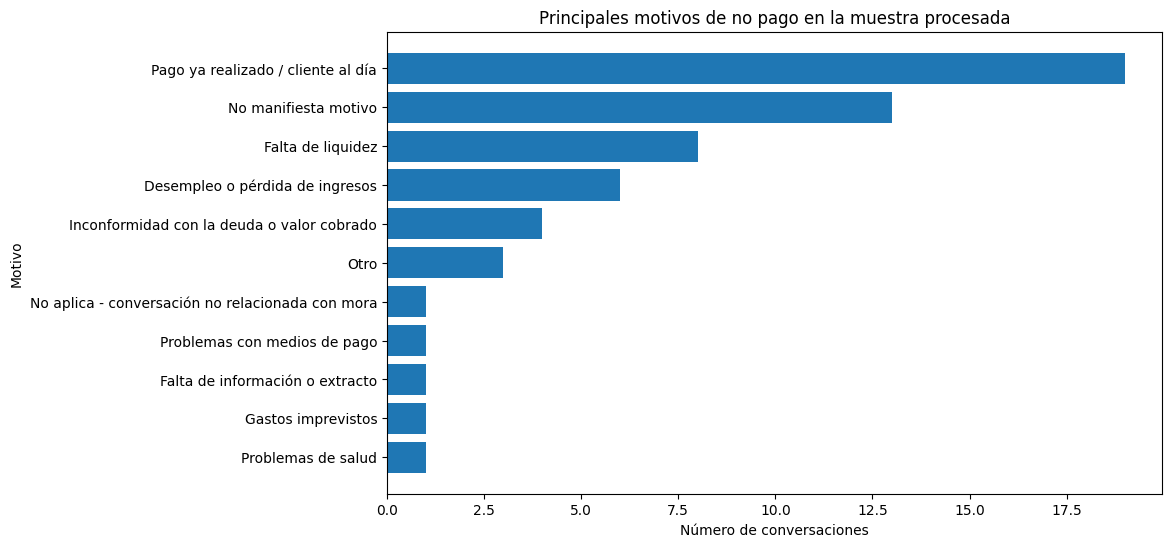

In [93]:
# ============================================
# 68. VISUALIZACIÓN DE MOTIVOS
# ============================================

plt.figure(figsize=(10, 6))

plt.barh(
    motivos_no_pago["motivo_no_pago"],
    motivos_no_pago["cantidad"]
)

plt.title("Principales motivos de no pago en la muestra procesada")
plt.xlabel("Número de conversaciones")
plt.ylabel("Motivo")

plt.gca().invert_yaxis()

plt.show()

### Hallazgo — Motivos de no pago

En la muestra procesada, el motivo más frecuente no corresponde a una incapacidad de pago,
sino a casos clasificados como **"Pago ya realizado / cliente al día"**.

Este resultado sugiere la existencia de oportunidades de mejora en la actualización de
información de cartera y en la sincronización entre pagos realizados y campañas de cobranza.

Entre los motivos asociados directamente a dificultad de pago destacan:

- Falta de liquidez.
- Desempleo o pérdida de ingresos.
- Inconformidad con la deuda o valor cobrado.

También se identificaron conversaciones en las que el cliente no manifiesta explícitamente
el motivo de no pago.

Dado que el análisis corresponde a una muestra procesada mediante IA, estos resultados
deben interpretarse como hallazgos exploratorios y no como estimaciones definitivas de toda
la operación.

## 13. Pregunta B — Ofertas realizadas por los asesores

**Pregunta de negocio:**  
¿Qué ofertas realizan los asesores para lograr un acuerdo de pago?

Se analiza la frecuencia de las acciones u ofrecimientos identificados
en las intervenciones de los asesores dentro de la muestra procesada.

In [94]:
# ============================================
# 69. DISTRIBUCIÓN DE OFERTAS
# ============================================

ofertas = (
    dataset_analitico["oferta_asesor"]
    .value_counts()
    .reset_index()
)

ofertas.columns = [
    "oferta_asesor",
    "cantidad"
]

ofertas["porcentaje"] = (
    ofertas["cantidad"]
    / ofertas["cantidad"].sum()
    * 100
).round(1)

display(ofertas)

,oferta_asesor,cantidad,porcentaje
0,Acuerdo o compromiso de pago,12,20.7
1,No realiza oferta,11,19.0
2,Refinanciación o reestructuración,11,19.0
3,Orientación a otro canal o área,6,10.3
4,Información de saldo,6,10.3
5,Alternativa de canal de pago,3,5.2
6,Nueva fecha de pago,3,5.2
7,Pago parcial,3,5.2
8,Pago total,2,3.4
9,Realización de abonos parciales a las cuotas más vencidas,1,1.7


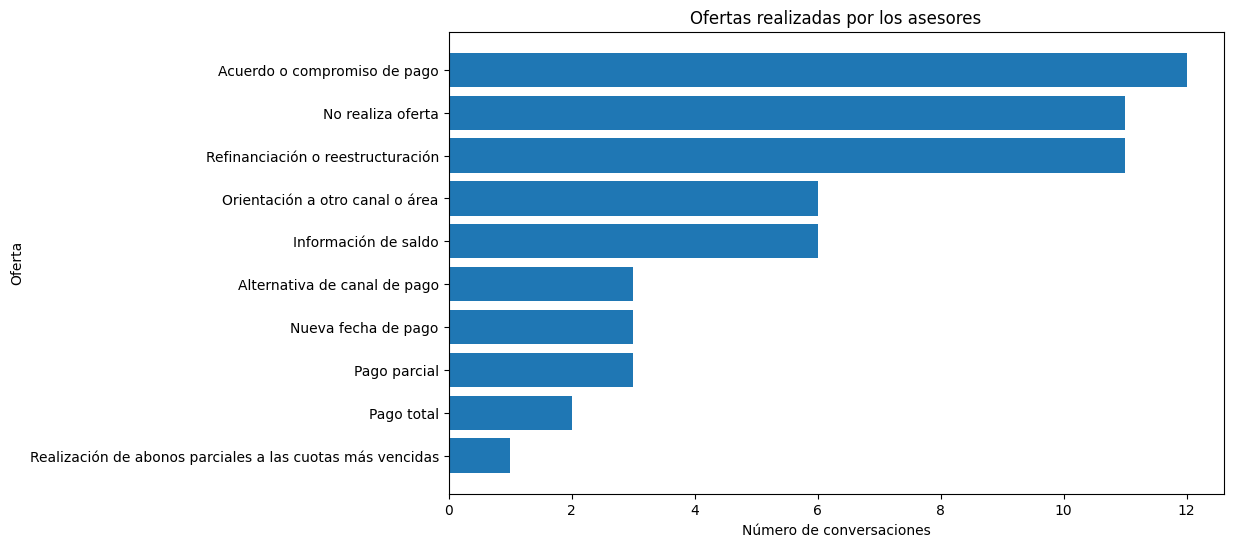

In [95]:
# ============================================
# 70. VISUALIZACIÓN DE OFERTAS
# ============================================

plt.figure(figsize=(10, 6))

plt.barh(
    ofertas["oferta_asesor"],
    ofertas["cantidad"]
)

plt.title("Ofertas realizadas por los asesores")
plt.xlabel("Número de conversaciones")
plt.ylabel("Oferta")

plt.gca().invert_yaxis()

plt.show()

### Hallazgo — Ofertas realizadas por los asesores

En la muestra procesada, las ofertas más frecuentes realizadas por los asesores fueron:

- Refinanciación o reestructuración.
- Acuerdo o compromiso de pago.
- Orientación a otro canal o área.
- Información de saldo.

También se identificó un grupo de conversaciones en las que el asesor no realizó una
oferta concreta de negociación.

Este resultado evidencia que la gestión de cobranza combina estrategias de negociación
con acciones de orientación e información, dependiendo del contexto particular del cliente.

Los resultados corresponden a la muestra procesada y deben interpretarse como hallazgos
exploratorios.

## 14. Pregunta C — Efectividad de ofertas y estrategias de negociación

**Pregunta de negocio:**  
¿Qué ofrecimientos o argumentos realizados por el asesor logran más acuerdos de pago?

La efectividad se calcula como la proporción de conversaciones que terminan
en acuerdo de pago dentro de cada tipo de oferta identificada.

In [96]:
# ============================================
# 71. EFECTIVIDAD POR TIPO DE OFERTA
# ============================================

efectividad_ofertas = (
    dataset_analitico
    .groupby("oferta_asesor")
    .agg(
        conversaciones=("uk_id_conversacion", "count"),
        acuerdos=("acuerdo_pago", "sum")
    )
    .reset_index()
)

efectividad_ofertas["tasa_acuerdo"] = (
    efectividad_ofertas["acuerdos"]
    / efectividad_ofertas["conversaciones"]
    * 100
).round(1)

efectividad_ofertas = (
    efectividad_ofertas
    .sort_values(
        "tasa_acuerdo",
        ascending=False
    )
)

display(efectividad_ofertas)

,oferta_asesor,conversaciones,acuerdos,tasa_acuerdo
0,Acuerdo o compromiso de pago,12,12,100.0
4,Nueva fecha de pago,3,2,66.7
6,Pago parcial,3,2,66.7
7,Pago total,2,1,50.0
1,Alternativa de canal de pago,3,1,33.3
9,Refinanciación o reestructuración,11,2,18.2
5,Orientación a otro canal o área,6,0,0.0
3,No realiza oferta,11,0,0.0
2,Información de saldo,6,0,0.0
8,Realización de abonos parciales a las cuotas más vencidas,1,0,0.0


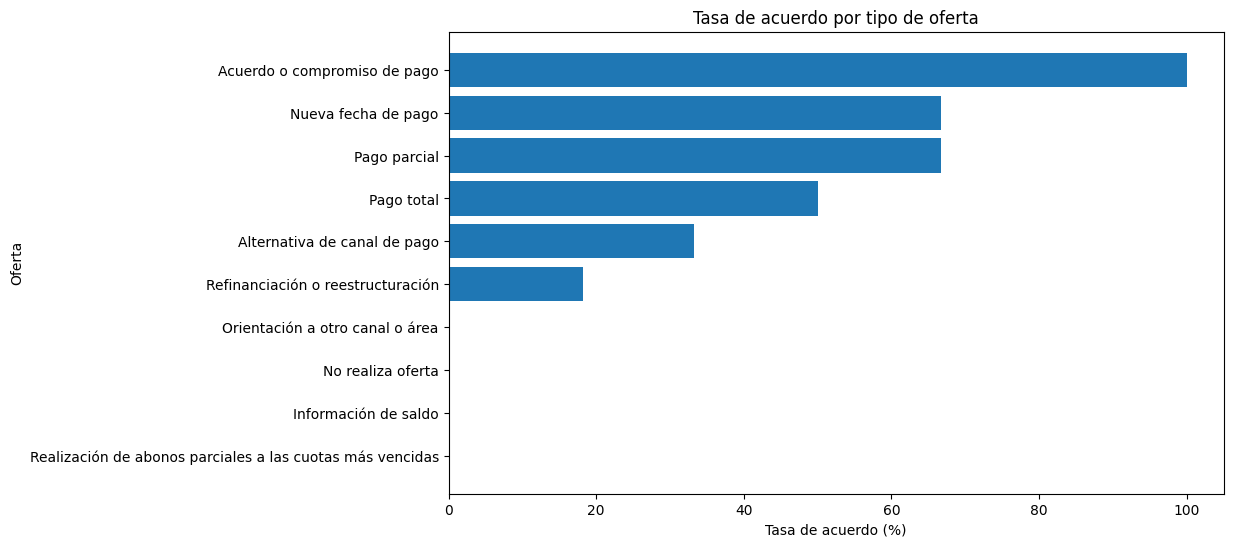

In [97]:
# ============================================
# 72. VISUALIZACIÓN DE EFECTIVIDAD
# ============================================

plt.figure(figsize=(10, 6))

plt.barh(
    efectividad_ofertas["oferta_asesor"],
    efectividad_ofertas["tasa_acuerdo"]
)

plt.title("Tasa de acuerdo por tipo de oferta")
plt.xlabel("Tasa de acuerdo (%)")
plt.ylabel("Oferta")

plt.gca().invert_yaxis()

plt.show()

### Hallazgo — Efectividad de ofertas y estrategias de negociación

En la muestra procesada, la estrategia con mayor tasa de acuerdo fue
**"Acuerdo o compromiso de pago"**, alcanzando una efectividad del 100%.

También se observaron tasas de acuerdo relevantes en:

- Alternativa de canal de pago.
- Nueva fecha de pago.

Por el contrario, las conversaciones clasificadas como
**"Refinanciación o reestructuración"** presentaron una tasa de acuerdo menor.

Este resultado sugiere que las estrategias más concretas, orientadas a definir
una acción inmediata de pago, pueden presentar una mayor efectividad que las
alternativas de negociación más amplias.

Sin embargo, debido al tamaño de la muestra procesada, estas tasas deben
interpretarse como hallazgos exploratorios y no como estimaciones definitivas
de desempeño para toda la operación.

## 15. Pregunta D — Resumen de las conversaciones

**Pregunta de negocio:**  
¿Qué está pasando en las conversaciones?

Para responder esta pregunta se utiliza la variable `resumen_conversacion`
generada mediante IA para cada interacción procesada.

El objetivo es sintetizar los principales hechos de cada conversación,
incluyendo motivo de contacto, gestión realizada por el asesor, resultado
de la interacción y existencia o no de acuerdo de pago.

In [98]:
# ============================================
# 73. RESÚMENES DE CONVERSACIONES
# ============================================

resumenes = dataset_analitico[
    [
        "uk_id_conversacion",
        "motivo_no_pago",
        "oferta_asesor",
        "acuerdo_pago",
        "resumen_conversacion"
    ]
].copy()

display(resumenes.head(10))

,uk_id_conversacion,motivo_no_pago,oferta_asesor,acuerdo_pago,resumen_conversacion
0,CONV_00000001,No manifiesta motivo,Acuerdo o compromiso de pago,True,El cliente se comunica para solicitar el valor pendiente y número de crédito para realizar el pago. El asesor le brinda los detalles y confirma un compromiso de pago para el 02/07. El usuario cali...
1,CONV_00000002,No aplica - conversación no relacionada con mora,No realiza oferta,False,La usuaria se comunicó para solicitar extractos del apartamento de su hija. El agente identificó que la usuaria no es la titular del producto y solicitó un poder autenticado. Al no contar con dich...
2,CONV_00000003,Pago ya realizado / cliente al día,Refinanciación o reestructuración,False,El cliente se comunica para informar que ya había realizado el pago el día lunes tras continuar recibiendo notificaciones de cobro. El asesor confirma que la obligación se encuentra al día y ofrec...
3,CONV_00000004,Desempleo o pérdida de ingresos,Orientación a otro canal o área,False,El cliente manifiesta tener dos cuotas atrasadas debido a la pérdida de su empleo y consulta sobre la cobertura del seguro. El agente le indica el procedimiento detallado para tramitar el siniestr...
4,CONV_00000005,Falta de información o extracto,Orientación a otro canal o área,False,El cliente indica que no realizó el pago debido a que no recibió el extracto y manifiesta disconformidad con el elevado monto de intereses. El asesor tramita la solicitud para enviar el extracto a...
5,CONV_00000006,Pago ya realizado / cliente al día,Información de saldo,False,"El cliente manifiesta haber realizado el pago de su obligación el día anterior mediante la opción de mínimo alterno disponible en la app. El agente le explica que, debido a los días de mora, dicho..."
6,CONV_00000007,Desempleo o pérdida de ingresos,Refinanciación o reestructuración,False,El cliente se comunica para solicitar una renegociación de su tarjeta Visa debido a una disminución de ingresos por temas personales. El asesor le ofrece diferir el saldo total a 96 meses con una ...
7,CONV_00000008,Falta de liquidez,Refinanciación o reestructuración,False,El cliente se contactó solicitando diferir el pago de sus tarjetas de crédito ya que sus compras quedaron a una sola cuota. El asesor recopiló sus datos de actualización y radicó la propuesta de r...
8,CONV_00000009,Problemas con medios de pago,Alternativa de canal de pago,False,El cliente contactó al servicio para pagar su tarjeta de crédito debido a problemas en la aplicación móvil con el botón PSE. El asesor le brindó los datos de la deuda y la guía detallada para comp...
9,CONV_00000010,Falta de liquidez,Refinanciación o reestructuración,True,El cliente solicitó una alternativa para su crédito vehicular debido a retrasos en su pago de nómina. El asesor gestionó la solicitud de traslado de dos cuotas para retomar el pago en agosto y aco...


In [99]:
# ============================================
# 74. EJEMPLOS DE RESÚMENES GENERADOS
# ============================================

for _, fila in resumenes.head(5).iterrows():

    print("=" * 100)
    print("CONVERSACIÓN:", fila["uk_id_conversacion"])
    print("Motivo:", fila["motivo_no_pago"])
    print("Oferta:", fila["oferta_asesor"])
    print("Acuerdo:", fila["acuerdo_pago"])

    print("\nResumen:")
    print(fila["resumen_conversacion"])

    print()

CONVERSACIÓN: CONV_00000001
Motivo: No manifiesta motivo
Oferta: Acuerdo o compromiso de pago
Acuerdo: True

Resumen:
El cliente se comunica para solicitar el valor pendiente y número de crédito para realizar el pago. El asesor le brinda los detalles y confirma un compromiso de pago para el 02/07. El usuario califica la atención con un 10 en la encuesta antes de finalizar el chat.

CONVERSACIÓN: CONV_00000002
Motivo: No aplica - conversación no relacionada con mora
Oferta: No realiza oferta
Acuerdo: False

Resumen:
La usuaria se comunicó para solicitar extractos del apartamento de su hija. El agente identificó que la usuaria no es la titular del producto y solicitó un poder autenticado. Al no contar con dicho documento, el agente explicó que no podía brindar la información y cerró la atención.

CONVERSACIÓN: CONV_00000003
Motivo: Pago ya realizado / cliente al día
Oferta: Refinanciación o reestructuración
Acuerdo: False

Resumen:
El cliente se comunica para informar que ya había realiz

### Hallazgo — Resumen automatizado de conversaciones

La IA Generativa permitió transformar conversaciones extensas de WhatsApp en
resúmenes ejecutivos de máximo tres oraciones.

Esta variable facilita la revisión rápida de grandes volúmenes de conversaciones
sin necesidad de leer individualmente todas las interacciones.

Los resúmenes permiten identificar de forma inmediata:

- Motivo principal del contacto.
- Situación del cliente.
- Gestión realizada por el asesor.
- Alternativa u oferta presentada.
- Resultado de la negociación.
- Existencia o no de acuerdo de pago.

Esta capacidad puede utilizarse operacionalmente para supervisión,
control de calidad y análisis Voice of Customer.

## 16. Pregunta E — Conversaciones con menor satisfacción

**Pregunta de negocio:**  
¿Qué características presentan las conversaciones con menor nivel de experiencia o satisfacción?

Para este análisis se utilizan, cuando están disponibles, las métricas explícitas de satisfacción, NPS y facilidad reportadas por el cliente.

Cuando no existe una evaluación explícita, se utiliza `experiencia_ia_score` como indicador inferido de experiencia conversacional.

Adicionalmente, se consideran el sentimiento del cliente, los factores negativos identificados y las recomendaciones generadas mediante IA para comprender las principales fuentes de fricción.

In [100]:
# ============================================
# 75. CINCO PEORES EXPERIENCIAS
# ============================================

peores_5 = (
    dataset_analitico
    .sort_values(
        by=[
            "experiencia_ia_score",
            "sentimiento_cliente"
        ],
        ascending=[
            True,
            True
        ]
    )
    .head(5)
    .copy()
)

display(
    peores_5[
        [
            "uk_id_conversacion",
            "experiencia_ia_score",
            "sentimiento_cliente",
            "motivo_no_pago",
            "oferta_asesor",
            "factores_negativos",
            "recomendacion"
        ]
    ]
)

,uk_id_conversacion,experiencia_ia_score,sentimiento_cliente,motivo_no_pago,oferta_asesor,factores_negativos,recomendacion
14,CONV_00000015,1,Muy negativo,Pago ya realizado / cliente al día,No realiza oferta,"['Falta de lectura y atención del asesor a la explicación previa del cliente', 'Uso rígido y repetitivo del guion por parte del asesor', 'Falta de respuesta oportuna al trámite de traslado de cuot...","Capacitar a los asesores en lectura analítica de la conversación antes de responder con guiones predeterminados, y establecer un canal prioritario para verificar y gestionar traslados de pago no a..."
17,CONV_00000018,1,Muy negativo,Pago ya realizado / cliente al día,No realiza oferta,"['Imposibilidad de gestionar la solicitud sin validación de datos', 'Molestia por cobros persistentes tras haber realizado el pago', 'Falta de alternativas o resolución por parte del asesor']",Brindar a los asesores protocolos o alternativas claras para guiar a clientes que reportan pagos ya realizados o que no disponen inmediatamente de sus datos de validación.
41,CONV_00000042,1,Muy negativo,No manifiesta motivo,Orientación a otro canal o área,"['Falta de resolución en solicitudes previas de acuerdos de pago', 'Falta de notificación al cliente sobre la cancelación de sus solicitudes', 'Cierre de la atención digital por atención simultáne...",Establecer notificaciones proactivas y claras sobre el estado o rechazo de solicitudes de acuerdos de pago para evitar que el cliente deba recurrir a múltiples canales sin respuesta.
4,CONV_00000005,2,Negativo,Falta de información o extracto,Orientación a otro canal o área,"['No recepción del extracto oportuno', 'Inconformidad con el monto de intereses cobrados', 'Incapacidad del agente para desglosar los valores adeudados en el mismo canal']",Facilitar la entrega inmediata y desglosada de estados de cuenta desde la misma gestión de cobranza para evitar fricción y renuencia al pago.
5,CONV_00000006,2,Negativo,Pago ya realizado / cliente al día,Información de saldo,"['Inconformidad con las políticas de aplicación del pago', 'Confusión generada por las opciones disponibles en la plataforma del banco']",Mejorar los mensajes de advertencia en la plataforma del banco para que el usuario sepa que el pago mínimo alterno no cubre la mora total cuando esta ya se generó.


In [101]:
# ============================================
# 76. DETALLE DE LAS CINCO PEORES CONVERSACIONES
# ============================================

for _, fila in peores_5.iterrows():

    print("=" * 100)
    print("CONVERSACIÓN:", fila["uk_id_conversacion"])
    print("Experiencia IA:", fila["experiencia_ia_score"])
    print("Sentimiento:", fila["sentimiento_cliente"])

    print("\nResumen:")
    print(fila["resumen_conversacion"])

    print("\nFactores negativos:")
    print(fila["factores_negativos"])

    print("\nRecomendación:")
    print(fila["recomendacion"])

    print()

CONVERSACIÓN: CONV_00000015
Experiencia IA: 1
Sentimiento: Muy negativo

Resumen:
El cliente explica que pagó su cuota con la referencia de un crédito anterior y que presentó una carta en el banco para el traslado del pago, pero no ha obtenido solución y sigue apareciendo en mora. La asesora ignora las explicaciones manifestadas y responde con preguntas estandarizadas de guion, lo que provoca la molestia del cliente. Tras el uso de lenguaje ofensivo por parte del usuario debido a la frustración, la atención es finalizada por la asesora.

Factores negativos:
['Falta de lectura y atención del asesor a la explicación previa del cliente', 'Uso rígido y repetitivo del guion por parte del asesor', 'Falta de respuesta oportuna al trámite de traslado de cuota presentado en oficina', 'Mala experiencia general con los canales de atención']

Recomendación:
Capacitar a los asesores en lectura analítica de la conversación antes de responder con guiones predeterminados, y establecer un canal priorit

In [102]:
# ============================================
# 77. CARACTERÍSTICAS DE LAS PEORES EXPERIENCIAS
# ============================================

print("Promedio de mensajes en las 5 peores:")
print(
    round(
        peores_5["total_mensajes"].mean(),
        1
    )
)

print("\nPromedio de participación del usuario:")
print(
    round(
        peores_5["participacion_usuario"].mean() * 100,
        1
    ),
    "%"
)

print("\nMotivos presentes:")
display(
    peores_5["motivo_no_pago"]
    .value_counts()
)

print("\nOfertas presentes:")
display(
    peores_5["oferta_asesor"]
    .value_counts()
)

Promedio de mensajes en las 5 peores:
46.8

Promedio de participación del usuario:
50.3 %

Motivos presentes:


,count
motivo_no_pago,
Pago ya realizado / cliente al día,3
No manifiesta motivo,1
Falta de información o extracto,1



Ofertas presentes:


,count
oferta_asesor,
No realiza oferta,2
Orientación a otro canal o área,2
Información de saldo,1


In [103]:
# ============================================
# 78. TABLA EJECUTIVA DE EXPERIENCIAS CRÍTICAS
# ============================================

tabla_peores = peores_5[
    [
        "uk_id_conversacion",
        "experiencia_ia_score",
        "sentimiento_cliente",
        "motivo_no_pago",
        "resumen_conversacion",
        "factores_negativos",
        "recomendacion"
    ]
].copy()

display(tabla_peores)

,uk_id_conversacion,experiencia_ia_score,sentimiento_cliente,motivo_no_pago,resumen_conversacion,factores_negativos,recomendacion
14,CONV_00000015,1,Muy negativo,Pago ya realizado / cliente al día,"El cliente explica que pagó su cuota con la referencia de un crédito anterior y que presentó una carta en el banco para el traslado del pago, pero no ha obtenido solución y sigue apareciendo en mo...","['Falta de lectura y atención del asesor a la explicación previa del cliente', 'Uso rígido y repetitivo del guion por parte del asesor', 'Falta de respuesta oportuna al trámite de traslado de cuot...","Capacitar a los asesores en lectura analítica de la conversación antes de responder con guiones predeterminados, y establecer un canal prioritario para verificar y gestionar traslados de pago no a..."
17,CONV_00000018,1,Muy negativo,Pago ya realizado / cliente al día,El cliente solicita dejar de recibir mensajes de cobro señalando que ya pagó. El asesor indica que no puede realizar ningún registro o consulta si no se valida la titularidad con los datos requeri...,"['Imposibilidad de gestionar la solicitud sin validación de datos', 'Molestia por cobros persistentes tras haber realizado el pago', 'Falta de alternativas o resolución por parte del asesor']",Brindar a los asesores protocolos o alternativas claras para guiar a clientes que reportan pagos ya realizados o que no disponen inmediatamente de sus datos de validación.
41,CONV_00000042,1,Muy negativo,No manifiesta motivo,El cliente manifiesta inconformidad debido a que sus solicitudes previas de acuerdo de pago han sido canceladas sin recibir notificación. Al informar que se encuentra en llamada simultánea con una...,"['Falta de resolución en solicitudes previas de acuerdos de pago', 'Falta de notificación al cliente sobre la cancelación de sus solicitudes', 'Cierre de la atención digital por atención simultáne...",Establecer notificaciones proactivas y claras sobre el estado o rechazo de solicitudes de acuerdos de pago para evitar que el cliente deba recurrir a múltiples canales sin respuesta.
4,CONV_00000005,2,Negativo,Falta de información o extracto,El cliente indica que no realizó el pago debido a que no recibió el extracto y manifiesta disconformidad con el elevado monto de intereses. El asesor tramita la solicitud para enviar el extracto a...,"['No recepción del extracto oportuno', 'Inconformidad con el monto de intereses cobrados', 'Incapacidad del agente para desglosar los valores adeudados en el mismo canal']",Facilitar la entrega inmediata y desglosada de estados de cuenta desde la misma gestión de cobranza para evitar fricción y renuencia al pago.
5,CONV_00000006,2,Negativo,Pago ya realizado / cliente al día,"El cliente manifiesta haber realizado el pago de su obligación el día anterior mediante la opción de mínimo alterno disponible en la app. El agente le explica que, debido a los días de mora, dicho...","['Inconformidad con las políticas de aplicación del pago', 'Confusión generada por las opciones disponibles en la plataforma del banco']",Mejorar los mensajes de advertencia en la plataforma del banco para que el usuario sepa que el pago mínimo alterno no cubre la mora total cuando esta ya se generó.


### Hallazgo — Conversaciones con menor satisfacción

Las conversaciones con menor nivel de experiencia permiten identificar
patrones de fricción relevantes para la operación.

Entre los factores a evaluar se encuentran:

- Falta de resolución de la solicitud.
- Explicaciones insuficientes o poco claras.
- Transferencias hacia otros canales o áreas.
- Esfuerzo elevado requerido al cliente.
- Inconformidad con valores cobrados.
- Contactos de cobranza cuando el cliente manifiesta haber pagado.
- Ausencia de alternativas adecuadas a la situación particular del cliente.

Las recomendaciones generadas buscan convertir estos factores en acciones
concretas de mejora sobre discurso, procesos, información disponible para
el asesor y resolución en primer contacto.

Los resultados corresponden a la muestra procesada y deben interpretarse
como patrones exploratorios.

## 17. Propuesta de solución RAG

### 17.1 Objetivo de la solución RAG

Se propone una arquitectura basada en Retrieval-Augmented Generation (RAG) para
estandarizar las respuestas entregadas a los clientes frente a los diferentes motivos
de no pago identificados durante la gestión de cobranza.

El objetivo es que el modelo generativo no responda únicamente a partir de su
conocimiento general, sino que consulte previamente una base de conocimiento
institucional y utilice únicamente información autorizada y vigente.

La solución busca:

- Reducir alucinaciones.
- Estandarizar el discurso de cobranza.
- Garantizar respuestas alineadas con políticas y procedimientos.
- Recomendar alternativas según el motivo de no pago.
- Mejorar la consistencia entre asesores.
- Facilitar la actualización de información sin necesidad de reentrenar el modelo.

### 17.2 Flujo general de la arquitectura

El flujo propuesto es:

1. El cliente envía un mensaje a través de WhatsApp.
2. El sistema identifica el motivo de no pago y el contexto de la conversación.
3. Se genera una representación vectorial o embedding de la consulta.
4. El sistema recupera información relevante desde una base vectorial.
5. El contenido recuperado se utiliza como contexto para el modelo generativo.
6. El LLM genera una respuesta basada exclusivamente en la información recuperada.
7. La respuesta pasa por reglas de validación y guardrails.
8. La respuesta puede ser sugerida al asesor o enviada automáticamente según el nivel de riesgo.

### 17.3 Arquitectura propuesta

```text
CLIENTE / WHATSAPP
        │
        ▼
Mensaje del cliente
        │
        ▼
Clasificación de intención
y motivo de no pago
        │
        ▼
Normalización de consulta
        │
        ▼
Generación de embedding
        │
        ▼
┌───────────────────────────────┐
│      VECTOR DATABASE          │
│                               │
│ Políticas de cobranza         │
│ Ofertas vigentes              │
│ Scripts aprobados             │
│ Procedimientos                │
│ Seguros y beneficios          │
│ Canales autorizados           │
│ Preguntas frecuentes          │
│ Casos de uso aprobados        │
└──────────────┬────────────────┘
               │
               ▼
Recuperación de contexto relevante
               │
               ▼
        Prompt enriquecido
               │
               ▼
              LLM
               │
               ▼
        Guardrails / reglas
               │
               ▼
Respuesta sugerida al asesor
               │
               ▼
            CLIENTE

### 17.4 Base de conocimiento

La calidad del RAG depende principalmente de la calidad de la información disponible
para recuperación.

La base de conocimiento debería incluir:

- Políticas vigentes de cobranza.
- Reglas para acuerdos de pago.
- Condiciones de refinanciación.
- Alternativas de pago permitidas.
- Beneficios o descuentos autorizados.
- Procedimientos frente a desempleo.
- Información sobre seguros asociados.
- Canales oficiales de atención y pago.
- Preguntas frecuentes.
- Scripts de negociación aprobados.
- Restricciones regulatorias.
- Procedimientos para reclamaciones.
- Casos de clientes que ya realizaron el pago.
- Manejo de inconsistencias de saldo.
- Procedimientos frente a problemas con extractos.

### 17.5 Preparación de documentos y chunking

Los documentos institucionales deben dividirse en fragmentos o `chunks`
antes de almacenarse en la base vectorial.

El objetivo del chunking es recuperar únicamente la parte del documento que sea
relevante para la consulta del cliente.

Se propone:

- Fragmentos de aproximadamente 300 a 800 tokens.
- Solapamiento entre fragmentos de aproximadamente 50 a 100 tokens.
- Separación respetando títulos, secciones y procedimientos.
- Conservación de metadata asociada a cada fragmento.

Ejemplo de metadata:

- tipo_documento
- producto
- motivo_no_pago
- fecha_vigencia
- versión
- canal
- nivel_riesgo
- política_asociada

Esta metadata permite filtrar la recuperación antes de aplicar similitud semántica.

### 17.6 Embeddings

Cada fragmento de la base de conocimiento se transforma en un vector numérico
mediante un modelo de embeddings.

Los embeddings representan el significado semántico del texto y permiten encontrar
documentos relevantes aunque la consulta del cliente no utilice exactamente las
mismas palabras.

Por ejemplo:

Cliente:
"No tengo trabajo y este mes no puedo pagar."

El sistema podría recuperar fragmentos relacionados con:

- desempleo,
- seguro de cuota protegida,
- requisitos para reclamación,
- canales de atención,
- condiciones del beneficio.

Este enfoque amplía el análisis realizado previamente con TF-IDF y similitud del coseno,
evolucionando hacia representaciones semánticas más robustas.

### 17.7 Base vectorial

Los embeddings generados deben almacenarse en una base vectorial.

Opciones posibles incluyen:

- FAISS.
- ChromaDB.
- Pinecone.
- Weaviate.
- Elasticsearch con búsqueda vectorial.
- PostgreSQL con pgvector.

Para una prueba de concepto se podría utilizar FAISS o ChromaDB.

Para un entorno productivo se recomienda una solución administrada que permita:

- escalabilidad,
- filtros por metadata,
- control de versiones,
- auditoría,
- alta disponibilidad,
- monitoreo.

### 17.8 Estrategia de recuperación

Ante una consulta del cliente, el sistema:

1. Detecta la intención y motivo de no pago.
2. Genera un embedding de la consulta.
3. Aplica filtros por metadata cuando sea posible.
4. Recupera los fragmentos más similares semánticamente.
5. Ordena los resultados por relevancia.
6. Envía únicamente los fragmentos más relevantes al LLM.

Se propone recuperar inicialmente entre 3 y 5 fragmentos.

También puede utilizarse un reranker para ordenar nuevamente los resultados y mejorar
la precisión antes de enviarlos al modelo generativo.

### 17.9 Generación de respuesta

El modelo generativo recibe:

- conversación reciente,
- motivo de no pago,
- perfil de la interacción,
- documentos recuperados,
- reglas de negocio,
- restricciones del canal.

Ejemplo conceptual de prompt:

"Responde al cliente utilizando únicamente el contexto institucional recuperado.
No inventes beneficios, tasas, descuentos, fechas o condiciones.
Si la información no está disponible, indica que se requiere validación por un asesor.
Utiliza un tono empático, claro y breve.
La respuesta debe estar alineada con las políticas de cobranza."

### 17.10 Guardrails y controles

Debido a que se trata de un proceso financiero, la solución debe incorporar controles antes de entregar una respuesta al cliente.

Se proponen los siguientes guardrails:

- No inventar tasas, descuentos o condiciones.
- No ofrecer alternativas no autorizadas.
- No modificar políticas vigentes.
- No generar amenazas o lenguaje coercitivo.
- No divulgar información personal.
- Validar identidad antes de mostrar información sensible.
- Rechazar respuestas sin evidencia documental suficiente.
- Escalar a un asesor humano en casos ambiguos.
- Registrar documentos utilizados para generar cada respuesta.
- Mantener trazabilidad de la versión de la política consultada.

### 17.11 Criterios de evaluación del RAG

La solución debe evaluarse tanto desde una perspectiva técnica como de negocio.

#### Evaluación de recuperación

- Recall@K.
- Precision@K.
- Mean Reciprocal Rank (MRR).
- Relevancia de los documentos recuperados.
- Cobertura de información necesaria.

#### Evaluación de generación

- Faithfulness: la respuesta está soportada por el contexto.
- Groundedness: no contiene afirmaciones no presentes en los documentos.
- Answer Relevance: responde realmente la pregunta del cliente.
- Exactitud factual.
- Cumplimiento de políticas.
- Tasa de alucinación.

#### Evaluación operacional

- Tiempo de respuesta.
- Latencia total.
- Disponibilidad del sistema.
- Tasa de escalamiento a humano.

#### Evaluación de negocio

- Tasa de acuerdos de pago.
- Recuperación efectiva.
- Resolución en primer contacto.
- Tiempo promedio de gestión.
- NPS.
- Satisfacción.
- Facilidad percibida.
- Reducción de reprocesos.

### 17.12 Evaluación mediante conjunto de referencia

Se recomienda construir un conjunto de evaluación con consultas reales y respuestas
esperadas validadas por expertos de cobranza.

Cada caso debería incluir:

- consulta del cliente,
- motivo de no pago,
- documentos que deberían ser recuperados,
- respuesta esperada,
- alternativas permitidas,
- restricciones aplicables.

Este conjunto serviría para evaluar automáticamente nuevas versiones del RAG antes
de desplegarlas en producción.

### 17.13 Ejemplo aplicado al caso de desempleo

**Mensaje del cliente:**

"Me quedé sin trabajo y no tengo cómo pagar la cuota este mes."

**Paso 1 — Clasificación**

Motivo:
`Desempleo o pérdida de ingresos`

**Paso 2 — Recuperación**

El sistema busca información relacionada con:

- seguro de desempleo,
- seguro de cuota protegida,
- condiciones de cobertura,
- requisitos,
- procedimiento,
- canal especializado.

**Paso 3 — Generación**

El LLM construye una respuesta utilizando únicamente la información recuperada.

Ejemplo:

"Entiendo tu situación. Tu producto puede contar con un beneficio asociado para
eventos de desempleo. Para validar si aplica en tu caso es necesario revisar las
condiciones de cobertura y realizar la solicitud por el canal autorizado.
Puedo indicarte el procedimiento correspondiente."

La respuesta debe ajustarse automáticamente a la información real recuperada desde
la base de conocimiento.

### 17.14 Ejemplo aplicado a cliente que ya realizó el pago

**Mensaje del cliente:**

"Yo ya pagué hace tres días y me siguen escribiendo."

El sistema debe evitar iniciar inmediatamente una negociación.

Debe recuperar:

- tiempos de aplicación del pago,
- procedimientos para validar pagos,
- canales de soporte,
- manejo de pagos no reflejados.

La respuesta debería priorizar la validación del pago y no realizar presión de cobranza.

Este caso resulta especialmente relevante debido a que
`Pago ya realizado / cliente al día` apareció como uno de los motivos más frecuentes
dentro de la muestra analizada.

### 17.15 Beneficios esperados de la solución RAG

La implementación de RAG permitiría:

- Estandarizar el discurso de cobranza.
- Reducir diferencias entre asesores.
- Disminuir respuestas incorrectas.
- Reducir alucinaciones del modelo generativo.
- Aumentar la trazabilidad de las respuestas.
- Mejorar resolución en primer contacto.
- Personalizar respuestas según el motivo de no pago.
- Mantener información actualizada sin reentrenar el LLM.
- Facilitar auditorías y control regulatorio.
- Generar recomendaciones consistentes de Next Best Action.

### 17.16 Evolución propuesta

La solución puede evolucionar desde un sistema de asistencia al asesor hacia un esquema
de automatización progresiva.

**Fase 1**
RAG como asistente: propone respuestas al asesor.

**Fase 2**
Respuesta automática en casos de bajo riesgo y alta confianza.

**Fase 3**
Integración con modelos predictivos de propensión de pago y Next Best Action.

**Fase 4**
Optimización continua de estrategias mediante experimentación y aprendizaje
a partir de resultados reales de negociación.

## 18. Metodologías analíticas complementarias

Además del uso de IA Generativa y RAG, se proponen algunas metodologías
complementarias que pueden fortalecer el análisis de las conversaciones
y mejorar la toma de decisiones en cobranza.

### 18.1 Análisis de sentimiento

El análisis de sentimiento permite identificar la percepción general del cliente
durante la conversación.

Puede utilizarse para clasificar interacciones como:

- Muy negativas.
- Negativas.
- Neutrales.
- Positivas.
- Muy positivas.

También puede analizarse la evolución del sentimiento durante la conversación,
por ejemplo:

Negativo → Neutral → Positivo

Esto permitiría identificar si la intervención del asesor mejora o deteriora
la experiencia del cliente.

Esta metodología se relaciona directamente con el análisis realizado en este proyecto,
donde se generó la variable `sentimiento_cliente` mediante IA.

### 18.2 Clustering semántico de conversaciones

El clustering permite agrupar conversaciones similares sin depender exclusivamente
de categorías definidas previamente.

A partir de embeddings o representaciones vectoriales pueden identificarse grupos
de conversaciones con patrones comunes.

Por ejemplo:

- Clientes con falta de liquidez.
- Clientes desempleados.
- Clientes inconformes con el valor cobrado.
- Clientes que ya realizaron el pago.
- Clientes con problemas de información o extractos.

Este análisis permitiría descubrir patrones adicionales que no hayan sido definidos
previamente dentro de la taxonomía.

### 18.3 A/B Testing de argumentos y ofertas

Para determinar qué argumentos o estrategias de negociación producen mejores
resultados se pueden realizar experimentos controlados.

Por ejemplo:

Grupo A:
El asesor utiliza un argumento orientado al beneficio de ponerse al día.

Grupo B:
El asesor utiliza un argumento orientado a una alternativa concreta de pago.

Posteriormente se comparan métricas como:

- Tasa de acuerdos.
- Pago efectivo.
- Satisfacción del cliente.
- Tiempo de gestión.

Esta metodología permitiría validar de manera más rigurosa qué discursos y ofertas
generan mejores resultados en la operación.

## 19. Principales hallazgos e insights

A partir del análisis exploratorio y de las variables generadas mediante IA,
se identificaron los siguientes hallazgos principales en la muestra procesada:

1. Una proporción relevante de conversaciones corresponde a clientes que manifiestan
   haber realizado previamente el pago o encontrarse al día.

2. Entre los motivos directamente asociados a dificultad de pago aparecen con mayor
   frecuencia la falta de liquidez y el desempleo o pérdida de ingresos.

3. Las estrategias de negociación más frecuentes incluyen refinanciación o
   reestructuración y acuerdos o compromisos de pago.

4. En la muestra analizada, las estrategias orientadas a concretar una acción de pago,
   como definir un compromiso o una nueva fecha, mostraron una mayor tasa de acuerdos.

5. Las conversaciones con menor experiencia presentan principalmente problemas de
   resolución, falta de claridad, esfuerzo elevado del cliente, transferencias a otros
   canales o inconformidad con la información recibida.

6. La automatización mediante IA permite transformar conversaciones extensas en
   variables estructuradas y resúmenes ejecutivos que facilitan la supervisión de la operación.

Estos resultados corresponden a la muestra procesada y deben interpretarse como
hallazgos exploratorios.

## 20. Recomendaciones de negocio

A partir de los hallazgos identificados se proponen las siguientes recomendaciones:

### 20.1 Mejorar la actualización de información de pagos

Fortalecer la sincronización entre los sistemas de recaudo y las campañas de cobranza
para reducir contactos a clientes que ya realizaron el pago.

### 20.2 Diseñar discursos diferenciados por motivo de no pago

No todos los clientes requieren la misma estrategia.

Por ejemplo:

- Falta de liquidez → alternativas flexibles de pago.
- Desempleo → validación de seguros o beneficios asociados.
- Pago ya realizado → validación del pago antes de continuar con cobranza.
- Inconformidad con deuda → explicación clara de valores y conceptos.
- Falta de extracto → solución operativa antes de exigir el pago.

### 20.3 Priorizar estrategias de negociación concretas

Los resultados exploratorios sugieren que las estrategias orientadas a definir
una acción concreta de pago presentan mejor efectividad que las alternativas
más generales.

### 20.4 Fortalecer la resolución en primer contacto

Reducir transferencias innecesarias entre áreas y entregar al asesor mayor
información para resolver la necesidad del cliente durante la misma interacción.

### 20.5 Implementar asistencia mediante RAG

Utilizar una solución RAG para entregar al asesor respuestas estandarizadas,
actualizadas y alineadas con las políticas de cobranza según el motivo identificado.

### 20.6 Implementar monitoreo continuo de experiencia

Utilizar sentimiento, satisfacción, esfuerzo y factores negativos para detectar
conversaciones críticas y orientar procesos de coaching y mejora continua.

## 21. Limitaciones y escalabilidad

El desarrollo presenta las siguientes limitaciones:

- El procesamiento mediante IA se realizó sobre una muestra debido a restricciones
  de cuota de la API durante la prueba técnica.
- El Gold Set utilizado para validación corresponde a una muestra piloto y no permite
  estimar de manera definitiva el desempeño del modelo sobre todo el universo.
- Algunas categorías, especialmente las relacionadas con ofertas del asesor,
  presentan solapamiento semántico.
- Las tasas de efectividad observadas deben interpretarse como exploratorias debido
  al tamaño de la muestra procesada.

Sin embargo, el pipeline desarrollado fue diseñado para escalar al total de las
1.197 conversaciones mediante procesamiento por lotes, checkpoints, manejo de errores
y recuperación del avance.

En un entorno productivo se recomienda ampliar el Gold Set, realizar validación humana
sobre una muestra estadísticamente representativa y monitorear continuamente la
calidad de las variables generadas.

## 22. Conclusiones

Este proyecto demuestra cómo la combinación de NLP, IA Generativa y analítica
conversacional permite transformar conversaciones no estructuradas de cobranza
en información accionable para el negocio.

El pipeline desarrollado permite:

- Identificar motivos de no pago.
- Clasificar ofertas y argumentos utilizados por los asesores.
- Detectar acuerdos de pago mediante reglas explícitas.
- Generar resúmenes automáticos.
- Analizar sentimiento y experiencia.
- Identificar conversaciones críticas.
- Evaluar la efectividad de estrategias de negociación.

Adicionalmente, se propone una arquitectura RAG para evolucionar desde el análisis
descriptivo hacia un sistema de asistencia inteligente al asesor, capaz de recuperar
información institucional y generar respuestas estandarizadas y contextualizadas.

La solución desarrollada constituye una prueba de concepto escalable que puede
extenderse al universo completo de conversaciones y evolucionar hacia capacidades
de optimización continua de la gestión de cobranza.